In [62]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re

import time
import torch
import torch.nn

import random
import pickle


In [63]:
if torch.cuda.is_available():
    print(torch.cuda.current_device())
    print(torch.cuda.device(0))
    print(torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))
else:
    print('CUDA is not available.')

0
1
NVIDIA A100-PCIE-40GB


In [64]:
import torch.backends.cudnn as cudnn
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    # work on a single GPU or CPU
    cudnn.benchmark=True
    print(torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    cudnn.benchmark=False

print(device)


NVIDIA A100-PCIE-40GB
cuda:0


In [65]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# 1. Load model

In [66]:
import io
import torch
# Reference: https://github.com/pytorch/pytorch/issues/16797#issuecomment-633423219
class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else: 
            return super().find_class(module, name)

In [6]:
### remove nan values
def remove_nan(y):
    nan_idx = np.where(pd.isna(y))[0]
    return y.drop(y.index[nan_idx], axis=0)

In [7]:
### Discretize the continuous variables into 2 or 3 categories - low, (moderate), high
def if_discretize(y_nonan):
    if y_nonan.dtype.name == 'object':
        y_disc = y_nonan
    elif len(np.unique(y_nonan)) <= 6:
        y_disc = y_nonan
    elif np.quantile(y_nonan, 1/2)==np.min(y_nonan):
        y_disc = pd.Series(np.where(y_nonan==np.min(y_nonan), 'Min', 'Not Min'), index=y_nonan.index)
    elif np.quantile(y_nonan, 1/2)==np.max(y_nonan):
        y_disc = pd.Series(np.where(y_nonan==np.max(y_nonan), 'Not Max', 'Max'), index=y_nonan.index)
    elif np.quantile(y_nonan, 1/3)==np.min(y_nonan) or np.quantile(y_nonan, 2/3)==np.max(y_nonan):
        y_disc = pd.qcut(y_nonan, 2, labels=['Low', 'High'])
    else:
        y_disc = pd.qcut(y_nonan, 3, labels=['Low', 'Moderate', 'High'])
    
    ### remove categories with less than 5 instances (8/2 training/testing split)
    u, c = np.unique(y_disc, return_counts=True)
    idx = np.where(np.isin(y_disc, u[c<5]))
    return y_disc.drop(index=y_disc.index[idx])

In [8]:
def balanced_over_sampling(X, y, random_seed=123):
    np.random.seed(random_seed)
    unique_value, unique_value_counts = np.unique(y, return_counts=True)
    train_class_max = np.max(unique_value_counts)
    train_samples_idx = []
    for i, y_unique in enumerate(unique_value):
        train_one_class_idx = np.where(y==y_unique)[0]
        train_one_sample_idx = np.concatenate([train_one_class_idx,
                                               np.random.choice(train_one_class_idx, 
                                                                size=train_class_max-len(train_one_class_idx), replace=True)])
        train_samples_idx.append(train_one_sample_idx)
    train_balanced_idx = np.random.permutation(np.concatenate(train_samples_idx))
    return X[train_balanced_idx], y[train_balanced_idx]

In [9]:
class Classifier(torch.nn.Module):
    def __init__(self, n_in_features, net_hidden_structure, n_out_features, dropout_rate):
        super(Classifier, self).__init__()
        net_fcs = []
        structure = net_hidden_structure
        net_in_shape = n_in_features
        for i, net_n_hidden_nodes in enumerate(structure):
            net_fcs.append(torch.nn.Linear(net_in_shape, net_n_hidden_nodes))
            net_fcs.append(torch.nn.BatchNorm1d(net_n_hidden_nodes))
            net_fcs.append(torch.nn.ReLU6())
            net_fcs.append(torch.nn.Dropout(p=dropout_rate))
            net_in_shape = net_n_hidden_nodes
        net_fcs.append(torch.nn.Linear(net_in_shape, n_out_features))
        self.net_fcs = torch.nn.ModuleList(net_fcs)
        
    def forward(self, x):
        net_fcs = self.net_fcs
        for net_fc in net_fcs:
            x = net_fc(x)
        return x

In [10]:
from torch.utils.data import Dataset, DataLoader
class Dataset(Dataset):
    """Self-defined dataset."""

    def __init__(self, X, y):
        """
        Args:
            X: microbiome data
            y: response data
        """
        self.X = torch.from_numpy(X).float() if not torch.is_tensor(X) else X.float()
        self.y = torch.LongTensor(y) if not torch.is_tensor(y) else y.long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [11]:
def load_model(X,y, disease, dropout_rate, weight_decay,
              lr=0.001, momentum=0.9, random_state=123, device='cuda:0', print_loss=True,
              save_folder='./'):
    
    import torch
    import torch.nn as nn
    import random
    torch.manual_seed(random_state)
    np.random.seed(random_state)
    random.seed(random_state)
    #torch.set_deterministic(True)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        
    ###
    y_nonan = remove_nan(y)
    y_nonan_disc = if_discretize(y_nonan)
    X_nonan = X.loc[y_nonan_disc.index,:]
    
    ### training, testing split
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(X_nonan, y_nonan_disc, test_size=0.2, 
                                                        random_state=random_state, stratify=y_nonan_disc)
    X_train_balanced, y_train_balanced = balanced_over_sampling(np.array(X_train), np.array(y_train))

    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    le.fit(y_nonan_disc)
    y_train_balanced_le = le.transform(y_train_balanced)
    y_test_le = le.transform(y_test)
    classes = le.classes_
    label_dim = len(classes)

    classifier = Classifier(n_in_features=X.shape[1], net_hidden_structure = [512, 128, 32, 8], 
                            n_out_features=label_dim, dropout_rate=dropout_rate)
    classifier.to(device)
    optimizer = torch.optim.SGD(classifier.parameters(), lr=lr, momentum=momentum, weight_decay = weight_decay)
    
    model_save_path = os.path.join(save_folder, 'models/{}/{}'.format(disease, y.name))

    ### If you are running on a CPU-only machine, add "map_location=torch.device('cpu')".
    if torch.cuda.is_available():
        checkpoint = torch.load(os.path.join(model_save_path, '{}.pth'.format(y_train.name)),
                                map_location=torch.device('cuda:0'))
    else:
        checkpoint = torch.load(os.path.join(model_save_path, '{}.pth'.format(y_train.name)), 
                                map_location=torch.device('cpu'))
        
    hist = checkpoint['history']
    classifier.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    return classifier, optimizer, hist, X_test, y_test_le, classes, X_nonan, y_nonan_disc

In [12]:
def micro_avg_auc(y_test_le, classes, pred_proba):
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    
    y_test = label_binarize(classes[y_test_le], classes=classes)
    if y_test.shape[1]==1:
        y_test = np.hstack((1-y_test, y_test))
    y_score = pred_proba.cpu().numpy()
    
    # Compute micro-average ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    return roc_auc

# 2. LRP

In [13]:
def get_activations(classifier, X, device='cuda:0'):
    activations = []
    classifier.to(device)
    classifier.eval()
    with torch.no_grad():
        _acti = torch.tensor(np.array([X])).float().to(device)
        for i, _module in enumerate(list(classifier.modules())[1]):
            _acti = _module(_acti)
            activations.append(_acti)
    return activations

In [14]:
### Reference: https://git.tu-berlin.de/gmontavon/lrp-tutorial
def rho1(w, a):
    aw = a.cpu().detach().numpy() * w.cpu().detach().numpy()
    return ((aw > 0) * w.cpu().detach().numpy()).squeeze()
def rho2(w, a):
    aw = a.cpu().detach().numpy() * w.cpu().detach().numpy()
    return ((aw < 0) * w.cpu().detach().numpy()).squeeze()
### LRP-epsilon
def incr(z, epsilon_coef=0.1): 
    return z + epsilon_coef * (z**2).mean()**.5

In [15]:
### Reference: https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py
import copy
def newlayer1(layer,g):

    layer = copy.deepcopy(layer)

    layer.weight = torch.nn.Parameter(torch.tensor(g(layer.weight)).to(device))
    layer.bias   = torch.nn.Parameter(torch.tensor(np.maximum(0,layer.bias.cpu().detach().numpy())).to(device))

    return layer

def newlayer2(layer,g):

    layer = copy.deepcopy(layer)

    layer.weight = torch.nn.Parameter(torch.tensor(g(layer.weight)).to(device))
    layer.bias   = torch.nn.Parameter(torch.tensor(np.minimum(0,layer.bias.cpu().detach().numpy())).to(device))

    return layer

In [16]:
def relprop(a, layer, R_k, alpha=2., beta=1., epsilon_coef=0.):
    import copy
    a1 = copy.deepcopy(a)
    z1 = newlayer1(layer, lambda x: rho1(x,a1.data)).forward(a1)         # step 1
    z1 = incr(z1, epsilon_coef)                                          # step 1
    if z1.abs().sum() == 0:
        R_j1 = torch.zeros_like(a1)  # Nothing to propagate
    else:
        s1 = R_k/(z1+1e-9)                                                   # step 2
        (z1*s1.data).sum().backward()                                        # step 3
        c1 = a1.grad                                                         # step 3
        R_j1 = alpha*a1*c1                                                   # step 4
    
    a2 = copy.deepcopy(a)
    z2 = newlayer2(layer, lambda x: rho2(x,a2.data)).forward(a2)          # step 1
    z2 = incr(z2, epsilon_coef)                                           # step 1
    if z2.abs().sum() == 0:
        R_j2 = torch.zeros_like(a2)  # Nothing to propagate
    else:
        s2 = R_k/(z2+1e-9)                                                    # step 2
        (z2*s2.data).sum().backward()                                         # step 3
        c2 = a2.grad                                                          # step 3
        R_j2 = beta*a2*c2                                                     # step 4
    return R_j1 - R_j2

In [17]:
def LRP(classifier, X_onerow, feature_idx, classes, device='cuda:0'):
    A = get_activations(classifier, X_onerow, device=device)
    A.insert(0, torch.FloatTensor(np.array(X_onerow)).to(device))
    LAYER = list(classifier.modules())[1]
    L = len(LAYER)
    R = [None]*(L+1)
    R[-1] = torch.tensor([0.0]*len(classes)).float().to(device)
    
    for idx in feature_idx:
        R[-1][idx] = A[-1].squeeze()[idx]
    for l in range(L)[::-1]:
        if isinstance(LAYER[l],torch.nn.Linear):
            A[l] = (A[l]).requires_grad_(True)
            R[l] = relprop(A[l], LAYER[l], R[l+1])
        else:
            R[l] = R[l+1]
    return R, A

In [18]:
### Reference: B-LRP - https://github.com/lapalap/B-LRP/blob/master/B_LRP_MNIST.ipynb

# Function for MinMax Normalisation of Relevances

def normalise_relevance(relevance_matrix):
    a = relevance_matrix.min()
    b = relevance_matrix.max()
    
    if (a == 0.) & (b == 0.):
        return relevance_matrix
    if (a >= 0.):
        return (relevance_matrix>=0.) * relevance_matrix/b
    if (b <= 0.):
        return - ((relevance_matrix<=0.) * relevance_matrix/a)
    else:
        return (relevance_matrix>0.) * relevance_matrix/b  - ((relevance_matrix<=0.)*relevance_matrix/a)


In [19]:
def lrp_analysis_clinical(classifier, X_microbiome, y_nonan_disc, classes, 
                          quantile_cut = 0.95, device='cuda:0', random_state=123):
    
    import torch
    import torch.nn as nn
    import random
    import numpy as np
    torch.manual_seed(random_state)
    np.random.seed(random_state)
    random.seed(random_state)
    #torch.set_deterministic(True)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        
    R_0_clinical, prediction = [], []
    for i in range(X_microbiome.shape[0]):
        y_feature_idx = np.where(classes==y_nonan_disc.iloc[i])[0]
        R_onerow, A_onerow = LRP(classifier, X_microbiome.iloc[i,:], y_feature_idx,
                                 classes, device=device)
        R_0_onerow = normalise_relevance(R_onerow[0]) ### Add minmax normalization here
        predict_onerow = A_onerow[-1].squeeze()[y_feature_idx]
        R_0_clinical.append(R_0_onerow.cpu().detach().numpy())
        prediction.append(predict_onerow.cpu().detach().numpy())
    R_0_clinical = np.array(R_0_clinical)
    prediction = np.array(prediction)
    
    ### Analysis on Relevance Score
    ### 1. Influence by row sum of absolute value of R0 (care about both excitatory and inhibitory effects)
    influence_by_microbe = np.sum(np.abs(R_0_clinical), axis=0)
    ### 2. significant count (by quantile/p-value)
    R_0_clinical_qcut = np.zeros(R_0_clinical.shape)
    for i in range(R_0_clinical.shape[0]):
        cutoff = np.quantile(R_0_clinical[i,:], quantile_cut)
        R_0_clinical_qcut[i,:] = R_0_clinical[i,:] >= cutoff
    ### 3. spearman correlation
    from scipy.stats import spearmanr
    correlation = []
    for j in range(R_0_clinical.shape[1]):
        if np.std(R_0_clinical[:, j]) > 0 and np.std(prediction) > 0:
            correlation.append(spearmanr(R_0_clinical[:, j], prediction).correlation)
        else:
            correlation.append(None)  # Append None for undefined cases when there are constant columns
    return R_0_clinical, R_0_clinical_qcut, influence_by_microbe, correlation

In [20]:
def lrp_analysis_clinical_all_cols(disease, nan_percentage_cutoff=0.4, quantile_cut = 0.95, auc_cutoff = [0.6, 0.6],
                                   device='cuda:0', save_folder='./', dropout_rate=0., weight_decay=0.):
    clinical_variables_disease_microbiome_clean = \
        pd.read_pickle('./data/processed data/{}_clinical_variables_disease_microbiome_clean.pkl'.format(disease))
    
    X_microbiome = pd.read_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))
    col_idx = clinical_variables_disease_microbiome_clean.shape[1] - X_microbiome.shape[1] - 4
    y_clinical_all = clinical_variables_disease_microbiome_clean.iloc[:, 2:col_idx]
    
    ### Remove columns that have >40% (or a preset value) nan values for all samples
    y_clinical_all_rmv_idx = np.where(y_clinical_all.\
                          apply(lambda x: sum(pd.isna(x))/len(x), axis=0) > nan_percentage_cutoff)[0]
    y_clinical_all.drop(columns=y_clinical_all.columns[y_clinical_all_rmv_idx], inplace=True)

    ### Remove columns with a single response
    y_1value_idx = y_clinical_all.apply(lambda x: len(np.unique(if_discretize(remove_nan(x)))), axis=0)==1
    y_clinical_all.drop(columns=y_clinical_all.columns[y_1value_idx], inplace=True)
            
    ### Remove columns with < 5 instances after discretization
    y_less5_ins_idx = y_clinical_all.apply(lambda y: if_discretize(remove_nan(y)).shape[0] < 5, axis=0)
    y_clinical_all.drop(columns=y_clinical_all.columns[y_less5_ins_idx], inplace=True)
    
    print(y_clinical_all.shape)
    
    import pickle
    with open(os.path.join(save_folder, 'results/{}/{}_prediction_result_dict.pkl'.\
                           format(disease, disease)), 'rb') as f:
        prediction_result_dict = pickle.load(f)
    
    # Screen by AUC value --> Micro avg. AUC >= auc_cutoff[0] AND Weighted avg. AUC >= auc_cutoff[1]
    micro_auc_clinical_variables = np.array([prediction_result_dict['auc'][x][0] for x in y_clinical_all.columns])
    weighted_auc_clinical_variables = np.array([prediction_result_dict['auc'][x][1] for x in y_clinical_all.columns])
    y_above_auc_idx = np.where((micro_auc_clinical_variables>=auc_cutoff[0]) & \
                               (weighted_auc_clinical_variables>=auc_cutoff[1]))[0]
    
    R_0_clinical_all, R_0_clinical_qcut_all, influence_by_microbe_all, correlation_all = \
        [], [], [], []
    for i in y_above_auc_idx:
        ### Load model
        classifier, optimizer, hist, X_test, y_test_le, classes, X_nonan, y_nonan_disc = \
            load_model(X=X_microbiome, y=y_clinical_all.iloc[:,i],
                       disease=disease, dropout_rate=dropout_rate, weight_decay=weight_decay)
        R_0_clinical, R_0_clinical_qcut, influence_by_microbe, correlation = \
            lrp_analysis_clinical(classifier, X_nonan, y_nonan_disc, classes, 
                                  quantile_cut = quantile_cut, device=device)
        R_0_clinical_all.append(R_0_clinical)
        R_0_clinical_qcut_all.append(R_0_clinical_qcut)
        influence_by_microbe_all.append(influence_by_microbe)
        correlation_all.append(correlation)
    y_col_names = y_clinical_all.columns.values[y_above_auc_idx]
    
    lrp_result_dict = dict()
    lrp_result_dict['R_0_clinical_all'] = R_0_clinical_all
    lrp_result_dict['R_0_clinical_qcut_all'] = R_0_clinical_qcut_all
    lrp_result_dict['influence_by_microbe_all'] = np.array(influence_by_microbe_all)
    lrp_result_dict['correlation_all'] = np.array(correlation_all)
    lrp_result_dict['y_col_names'] = y_col_names
    
    import pickle
    result_save_folder = os.path.join(save_folder, 'results/LRP/{}'.format(disease))
    os.makedirs(result_save_folder, exist_ok=True)
    
    with open(os.path.join(result_save_folder, 'lrp_result_dict.pkl'), "wb") as f:
        pickle.dump(lrp_result_dict, f)
        
    return lrp_result_dict

In [21]:
%%time
COAD_lrp_result_dict = lrp_analysis_clinical_all_cols('COAD', device=device, nan_percentage_cutoff=0.4, dropout_rate=0.6, weight_decay=0.)
print(len(COAD_lrp_result_dict['y_col_names']))
print(COAD_lrp_result_dict['y_col_names'])

(246, 36)
7
['race' 'initial_pathologic_dx_year' 'DSS' 'msi_status' 'Proliferation'
 'Number of Segments' 'CTA Score']
CPU times: user 1min 56s, sys: 7min 15s, total: 9min 12s
Wall time: 1min 26s


In [22]:
%%time
STAD_lrp_result_dict = lrp_analysis_clinical_all_cols('STAD', device=device, nan_percentage_cutoff=0.4, dropout_rate=0.6, weight_decay=0.)
print(len(STAD_lrp_result_dict['y_col_names']))
print(STAD_lrp_result_dict['y_col_names'])

(380, 38)
9
['race' 'initial_pathologic_dx_year' 'treatment_outcome_first_course'
 'DSS' 'PFI' 'ethnicity' 'radiation_therapy' 'Wound Healing'
 'Number of Segments']
CPU times: user 3min 49s, sys: 13min 56s, total: 17min 45s
Wall time: 2min 45s


In [23]:
%%time
LUAD_lrp_result_dict = lrp_analysis_clinical_all_cols('LUAD', device=device, nan_percentage_cutoff=0.4, dropout_rate=0.4, weight_decay=0.01)
print(len(LUAD_lrp_result_dict['y_col_names']))
print(LUAD_lrp_result_dict['y_col_names'])

(502, 34)
6
['race' 'initial_pathologic_dx_year' 'vital_status' 'OS (dead=1)' 'DSS'
 'Proliferation']
CPU times: user 4min 5s, sys: 16min 1s, total: 20min 7s
Wall time: 2min 18s


In [24]:
%%time
LUSC_lrp_result_dict = lrp_analysis_clinical_all_cols('LUSC', device=device, nan_percentage_cutoff=0.4, dropout_rate=0.6, weight_decay=0.)
print(len(LUSC_lrp_result_dict['y_col_names']))
print(LUSC_lrp_result_dict['y_col_names'])

(464, 35)
10
['race' 'initial_pathologic_dx_year' 'tumor_status'
 'treatment_outcome_first_course' 'DFI.time (days)' 'ethnicity'
 'radiation_therapy' 'Stromal Fraction' 'Proliferation' 'Wound Healing']
CPU times: user 6min 31s, sys: 22min 35s, total: 29min 6s
Wall time: 2min 47s


---

In [67]:
def taxa_to_genera_taxid(taxa_names_with_ids):
    genus_name = [idx.split('-')[0] for idx in taxa_names_with_ids]
    taxid = [int(idx.split('-')[1]) for idx in taxa_names_with_ids]
    return genus_name, taxid

In [68]:
def genus_lvl_marker_by_LRP(disease, influence_quantile_cutoff=0.95, save = True):
    with open(os.path.join(f'./results/LRP/{disease}', 'lrp_result_dict.pkl'), 'rb') as f:
        lrp_result_dict = CPU_Unpickler(f).load()
    X_microbiome = pd.read_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))

    influence_genera_dict, marker_genera_dict = {}, {}
    for i, cov in enumerate(lrp_result_dict['y_col_names']):
        influence_by_cov = pd.Series(lrp_result_dict['influence_by_microbe_all'][i,:],
                                     index=X_microbiome.columns)

        influence_genera_dict[cov] = influence_by_cov.sort_values(ascending=False)
        influence_cutoff = np.quantile(influence_genera_dict[cov], influence_quantile_cutoff)
        marker_genera_dict[cov] = \
            np.array(influence_genera_dict[cov].index)[influence_genera_dict[cov] >= influence_cutoff]
    if save:
        lrp_result_dict['influence_genera_dict'] = influence_genera_dict
        lrp_result_dict['marker_genera_dict'] = marker_genera_dict
        with open(os.path.join(f'./results/LRP/{disease}', 'lrp_result_dict.pkl'), "wb") as f:
            pickle.dump(lrp_result_dict, f)
    return influence_genera_dict, marker_genera_dict

In [27]:
COAD_influence_dict, COAD_marker_genera_dict = genus_lvl_marker_by_LRP('COAD')

In [28]:
STAD_influence_dict, STAD_marker_genera_dict = genus_lvl_marker_by_LRP('STAD')

In [29]:
LUAD_influence_dict, LUAD_marker_genera_dict = genus_lvl_marker_by_LRP('LUAD')

In [30]:
LUSC_influence_dict, LUSC_marker_genera_dict = genus_lvl_marker_by_LRP('LUSC')

## Sorted AUC scores

In [69]:
def sorted_auc(disease, print_disease_name=True):
    import os
    import pickle
    with open(os.path.join(f'./results/{disease}', f'{disease}_prediction_result_dict.pkl'), 'rb') as f:
        prediction_result_dict = CPU_Unpickler(f).load()
    with open(os.path.join(f'./results/LRP/{disease}', 'lrp_result_dict.pkl'), 'rb') as f:
        lrp_result_dict = CPU_Unpickler(f).load() 
    covariate_list = lrp_result_dict['y_col_names']
    all_auc_dict = prediction_result_dict['auc']
    auc_dict = dict(zip(covariate_list, [all_auc_dict[i] for i in covariate_list]))
    sorted_auc_dict = dict(sorted(auc_dict.items(), key = lambda item: item[1][0]+item[1][1], reverse=True))
    sorted_auc_df = pd.DataFrame({'Covariate': sorted_auc_dict.keys(),
                                  '(M-Avg AUC, W-Avg AUC)': sorted_auc_dict.values()},
                                 index = [f'Covariate {i+1}' for i in range(len(covariate_list))])
    if print_disease_name: print(disease)
    return sorted_auc_df

In [70]:
def top_n_genera_name(disease, covariate_list, n=5, m=None):
    with open(os.path.join('./results/LRP/{}/lrp_result_dict.pkl'.format(disease)), "rb") as f:
        lrp_result_dict = CPU_Unpickler(f).load()

    X_microbiome = pd.read_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))
    influence_by_microbe_all_df = pd.DataFrame(lrp_result_dict['influence_by_microbe_all'],
                                            index=lrp_result_dict['y_col_names'], columns=X_microbiome.columns)
    
    all_taxa_name_list = []
    for cov in covariate_list:
        onerow = influence_by_microbe_all_df.loc[cov, :]
        ranked_name = influence_by_microbe_all_df.columns[np.argsort(onerow.values)[::-1]]
        trailing = '' if m is None else '.'
        ranked_genera_name = [ranked_name[i].split('-')[0][slice(m)] + trailing for i in range(len(onerow))]
        all_taxa_name_list.append(ranked_genera_name[:n])
    all_taxa_name_dict = dict(zip(covariate_list, all_taxa_name_list))
    return all_taxa_name_dict

In [71]:
COAD_sorted_auc_df = sorted_auc('COAD')
COAD_sorted_auc_df

COAD


,Covariate,"(M-Avg AUC, W-Avg AUC)"
Covariate 1,race,"(0.8811679492983251, 0.7802632419653697)"
Covariate 2,DSS,"(0.8440453686200378, 0.6375)"
Covariate 3,msi_status,"(0.7427536231884059, 0.6149504195270785)"
Covariate 4,initial_pathologic_dx_year,"(0.6251561849229487, 0.6314925970388156)"
Covariate 5,Proliferation,"(0.6156, 0.6170231729055259)"
Covariate 6,Number of Segments,"(0.6182, 0.6133689839572193)"
Covariate 7,CTA Score,"(0.6063368055555556, 0.6048177083333334)"


In [72]:
COAD_top_5_full_genera_name = top_n_genera_name('COAD', COAD_sorted_auc_df['Covariate'])

COAD_top_5_genera_name_df = pd.DataFrame({
    'Covariate': COAD_top_5_full_genera_name.keys(),
    'Full_name_top5': COAD_top_5_full_genera_name.values()
})

# read abbreviation dictionary table
top_5_genera_dictionary_df = pd.read_csv('../top_5_genera_dictionary_df.csv')

# build mapping: full name -> abbreviation
top_5_genera_dictionary_dict = dict(
    zip(
        top_5_genera_dictionary_df['Full names'],
        top_5_genera_dictionary_df['Abbreviations']
    )
)

# map top-5 full names to abbreviations using dictionary table
COAD_top_5_abbr_list = []
missing_names = set()

for genera_list in COAD_top_5_genera_name_df['Full_name_top5']:
    abbr_list = []
    for genus in genera_list:
        if genus in top_5_genera_dictionary_dict:
            abbr_list.append(top_5_genera_dictionary_dict[genus])
        else:
            abbr_list.append(None)  
            missing_names.add(genus)
    COAD_top_5_abbr_list.append(abbr_list)

COAD_top_5_genera_name_df['Abbreviations_top5'] = COAD_top_5_abbr_list

# check if anything was missing from the dictionary
if missing_names:
    print("Missing genera in abbreviation dictionary:")
    print(sorted(missing_names))

COAD_top_5_genera_name_df

,Covariate,Full_name_top5,Abbreviations_top5
0,race,"[Bacillus, Klebsiella, Escherichia, Leisingera...","[Baci., Kleb., Esch., Leis., Cuti.]"
1,DSS,"[Bacillus, Pseudomonas, Klebsiella, Enterobact...","[Baci., Pseu.m., Kleb., Ente.b., Neis.]"
2,msi_status,"[Klebsiella, Bacillus, Escherichia, Pseudomona...","[Kleb., Baci., Esch., Pseu.m., Salm.]"
3,initial_pathologic_dx_year,"[Bacillus, Klebsiella, Escherichia, Cohnella, ...","[Baci., Kleb., Esch., Cohn., Pseu.m.]"
4,Proliferation,"[Klebsiella, Escherichia, Bacillus, Pseudomona...","[Kleb., Esch., Baci., Pseu.m., Coma.]"
5,Number of Segments,"[Bacillus, Escherichia, Pseudomonas, Klebsiell...","[Baci., Esch., Pseu.m., Kleb., Cuti.]"
6,CTA Score,"[Bacillus, Escherichia, Klebsiella, Pseudomona...","[Baci., Esch., Kleb., Pseu.m., Rhiz.]"


In [73]:
# load saved LRP results
with open(os.path.join('./results/LRP/COAD', 'lrp_result_dict.pkl'), 'rb') as f:
    lrp_result_dict = CPU_Unpickler(f).load()

# extract marker dict
COAD_marker_genera_dict = lrp_result_dict['marker_genera_dict']

import re
COAD_marker_genera_df = pd.DataFrame({'Features': COAD_sorted_auc_df['Covariate'],
                                      'Microbial biomarkers': [re.sub('[\[\]]', '', str(list(COAD_marker_genera_dict[i]))) for i in COAD_sorted_auc_df['Covariate'].values]})
COAD_marker_genera_df

,Features,Microbial biomarkers
Covariate 1,race,"'Bacillus-1386', 'Klebsiella-570', 'Escherichi..."
Covariate 2,DSS,"'Bacillus-1386', 'Pseudomonas-286', 'Klebsiell..."
Covariate 3,msi_status,"'Klebsiella-570', 'Bacillus-1386', 'Escherichi..."
Covariate 4,initial_pathologic_dx_year,"'Bacillus-1386', 'Klebsiella-570', 'Escherichi..."
Covariate 5,Proliferation,"'Klebsiella-570', 'Escherichia-561', 'Bacillus..."
Covariate 6,Number of Segments,"'Bacillus-1386', 'Escherichia-561', 'Pseudomon..."
Covariate 7,CTA Score,"'Bacillus-1386', 'Escherichia-561', 'Klebsiell..."


In [74]:
STAD_sorted_auc_df = sorted_auc('STAD')
STAD_sorted_auc_df

STAD


,Covariate,"(M-Avg AUC, W-Avg AUC)"
Covariate 1,ethnicity,"(0.9958448753462604, 0.8839285714285714)"
Covariate 2,race,"(0.884161283136556, 0.7573542543691796)"
Covariate 3,treatment_outcome_first_course,"(0.852294921875, 0.7058247511350851)"
Covariate 4,initial_pathologic_dx_year,"(0.7098337950138504, 0.721163967611336)"
Covariate 5,DSS,"(0.7635030864197531, 0.6470588235294118)"
Covariate 6,radiation_therapy,"(0.7884898130644822, 0.6025974025974026)"
Covariate 7,Number of Segments,"(0.653306786703601, 0.665)"
Covariate 8,PFI,"(0.6350415512465375, 0.6462339743589745)"
Covariate 9,Wound Healing,"(0.609851108033241, 0.6118575851393189)"


In [75]:
STAD_top_5_full_genera_name = top_n_genera_name('STAD', STAD_sorted_auc_df['Covariate'])

STAD_top_5_genera_name_df = pd.DataFrame({
    'Covariate': STAD_top_5_full_genera_name.keys(),
    'Full_name_top5': STAD_top_5_full_genera_name.values()
})

# read abbreviation dictionary table
top_5_genera_dictionary_df = pd.read_csv('../top_5_genera_dictionary_df.csv')

# build mapping: full name -> abbreviation
top_5_genera_dictionary_dict = dict(
    zip(
        top_5_genera_dictionary_df['Full names'],
        top_5_genera_dictionary_df['Abbreviations']
    )
)

# map top-5 full names to abbreviations using dictionary table
STAD_top_5_abbr_list = []
missing_names = set()

for genera_list in STAD_top_5_genera_name_df['Full_name_top5']:
    abbr_list = []
    for genus in genera_list:
        if genus in top_5_genera_dictionary_dict:
            abbr_list.append(top_5_genera_dictionary_dict[genus])
        else:
            abbr_list.append(None)  
            missing_names.add(genus)
    STAD_top_5_abbr_list.append(abbr_list)

STAD_top_5_genera_name_df['Abbreviations_top5'] = STAD_top_5_abbr_list

# check if anything was missing from the dictionary
if missing_names:
    print("Missing genera in abbreviation dictionary:")
    print(sorted(missing_names))

STAD_top_5_genera_name_df

,Covariate,Full_name_top5,Abbreviations_top5
0,ethnicity,"[Burkholderia, Klebsiella, Pseudomonas, Entero...","[Burk., Kleb., Pseu.m., Ente.b., Brad.]"
1,race,"[Klebsiella, Bradyrhizobium, Campylobacter, Es...","[Kleb., Brad., Camp., Esch., Myco.]"
2,treatment_outcome_first_course,"[Shigella, Escherichia, Cutibacterium, Bacillu...","[Shig., Esch., Cuti., Baci., Burk.]"
3,initial_pathologic_dx_year,"[Salmonella, Bacillus, Klebsiella, Bradyrhizob...","[Salm., Baci., Kleb., Brad., Acin.]"
4,DSS,"[Klebsiella, Shigella, Bradyrhizobium, Stenotr...","[Kleb., Shig., Brad., Sten., Pseu.m.]"
5,radiation_therapy,"[Bacillus, Escherichia, Candidatus Pelagisphae...","[Baci., Esch., Cand.p., Salm., Brad.]"
6,Number of Segments,"[Escherichia, Klebsiella, Salmonella, Enteroba...","[Esch., Kleb., Salm., Ente.b., Ente.c.]"
7,PFI,"[Shigella, Klebsiella, Pseudomonas, Salmonella...","[Shig., Kleb., Pseu.m., Salm., Stre.m.]"
8,Wound Healing,"[Pseudomonas, Escherichia, Plantactinospora, S...","[Pseu.m., Esch., Plan., Salm., Cuti.]"


In [76]:
COAD_top_5_genera_name_df.to_pickle('./results/clinical_COAD_top_5_genera_name.pkl')
STAD_top_5_genera_name_df.to_pickle('./results/clinical_STAD_top_5_genera_name.pkl')

In [77]:
# load saved LRP results
with open(os.path.join('./results/LRP/STAD', 'lrp_result_dict.pkl'), 'rb') as f:
    lrp_result_dict = CPU_Unpickler(f).load()

# extract marker dict
STAD_marker_genera_dict = lrp_result_dict['marker_genera_dict']

import re
STAD_marker_genera_df = pd.DataFrame({'Features': STAD_sorted_auc_df['Covariate'],
                                      'Microbial biomarkers': [re.sub('[\[\]]', '', str(list(STAD_marker_genera_dict[i]))) for i in STAD_sorted_auc_df['Covariate'].values]})
STAD_marker_genera_df

,Features,Microbial biomarkers
Covariate 1,ethnicity,"'Burkholderia-32008', 'Klebsiella-570', 'Pseud..."
Covariate 2,race,"'Klebsiella-570', 'Bradyrhizobium-374', 'Campy..."
Covariate 3,treatment_outcome_first_course,"'Shigella-620', 'Escherichia-561', 'Cutibacter..."
Covariate 4,initial_pathologic_dx_year,"'Salmonella-590', 'Bacillus-1386', 'Klebsiella..."
Covariate 5,DSS,"'Klebsiella-570', 'Shigella-620', 'Bradyrhizob..."
Covariate 6,radiation_therapy,"'Bacillus-1386', 'Escherichia-561', 'Candidatu..."
Covariate 7,Number of Segments,"'Escherichia-561', 'Klebsiella-570', 'Salmonel..."
Covariate 8,PFI,"'Shigella-620', 'Klebsiella-570', 'Pseudomonas..."
Covariate 9,Wound Healing,"'Pseudomonas-286', 'Escherichia-561', 'Plantac..."


In [78]:
COAD_marker_genera_df.to_csv('./results/COAD/COAD_marker_genera.csv', index=False)
STAD_marker_genera_df.to_csv('./results/STAD/STAD_marker_genera.csv', index=False)

---

## ROC curves for Figures

In [42]:
def roc_curve_all(disease, fig_save_folder='./figures/ROC', variables=None, fontsize=30, bbox_to_anchor=(1.03, -0.03), 
                  plot_axis='x1y1', plot_num_per_row=5, save_format='pdf'):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    import os

    pred_result_save_folder = './results/%s' % disease
    with open(os.path.join(pred_result_save_folder, '{}_prediction_result_dict.pkl'.format(disease)), 'rb') as f:
        prediction_result_dict = CPU_Unpickler(f).load()

    lrp_result_save_folder = './results/LRP/%s' % disease
    with open(os.path.join(lrp_result_save_folder, 'lrp_result_dict.pkl'.format(disease)), "rb") as f:
        lrp_result_dict = CPU_Unpickler(f).load()

    covariate_list = lrp_result_dict['y_col_names']
    all_auc_dict = prediction_result_dict['auc']
    auc_dict = dict(zip(covariate_list, [all_auc_dict[i] for i in covariate_list]))
    sorted_auc_dict = dict(sorted(auc_dict.items(), key = lambda item: item[1][0]+item[1][1], reverse=True))
    
    if variables is None:
        plot_var = list(sorted_auc_dict.keys())
    else:
        plot_var = variables 
        
    n_row = np.ceil(len(plot_var)/plot_num_per_row)
    n_full_col = len(plot_var)%plot_num_per_row if len(plot_var)%plot_num_per_row != 0 else 5
       
    for idx, cov in enumerate(list(plot_var)):
        y_test_cov = prediction_result_dict['y_train_test'][cov][1]

        y_test = label_binarize(y_test_cov.values, classes=prediction_result_dict['classes'][cov])
        if y_test.shape[1]==1:
            y_test = np.hstack((1-y_test, y_test))
        y_score = prediction_result_dict['pred_proba'][cov].cpu().numpy()
        classes = prediction_result_dict['classes'][cov]
        print(cov, '\n', classes)
        
        # Reference: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        tt = dict()
        
        for i, c in enumerate(classes):
            if sum(y_test[:, i]) == 0:
                continue
            fpr[c], tpr[c], tt[c] = roc_curve(y_test[:, i], y_score[:, i])
            roc_auc[c] = auc(fpr[c], tpr[c])
            
        # Compute micro-average ROC curve and ROC area
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Compute macro-average ROC curve and ROC area
        # First aggregate all false positive rates
        all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))

        # Then interpolate all ROC curves at this points with prevelence as weights
        mean_tpr = np.zeros_like(all_fpr)
        for i in classes:
            mean_tpr += np.sum(y_test_cov == i) * np.interp(all_fpr, fpr[i], tpr[i])

        # Finally average it and compute weighted average AUC
        mean_tpr /= len(y_test_cov)
        
        mean_tpr = np.insert(mean_tpr, [0, len(mean_tpr)], [0., 1.])
        all_fpr = np.insert(all_fpr, [0, len(all_fpr)], [0., 1.])

        fpr["weighted"] = all_fpr
        tpr["weighted"] = mean_tpr
        roc_auc["weighted"] = auc(fpr["weighted"], tpr["weighted"])
        
        stored_auc = prediction_result_dict['auc'][cov]
        
        fig, ax = plt.subplots(figsize=(8,8))

        # Remove grid and background
        plt.style.use('default')  # Reset to default style
        ax.set_facecolor('white')
        fig.set_facecolor('white')
        plt.grid(False)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        lw = 2
        
#         import matplotlib
#         cmap = matplotlib.cm.get_cmap('Set1')

        plt.plot(
        fpr['micro'],
        tpr['micro'],
        lw=lw,
#         color=cmap(0),
        label=f"M-Avg.: {stored_auc[0]:0.2f}"
        )
        
        plt.plot(
        fpr['weighted'],
        tpr['weighted'],
        lw=lw,
#         color=cmap(1),
        label=f"W-Avg.: {stored_auc[1]:0.2f}"
        )
        legend_properties = {'weight':'bold', 'size':fontsize}
        plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
        
        if plot_axis == 'default':
            if idx%plot_num_per_row == 0 and idx//plot_num_per_row == n_row-1: axis = 'x1y1'
            elif idx%plot_num_per_row == 0: axis = 'x0y1'
            elif idx//plot_num_per_row == n_row-1: axis = 'x1y0'
            elif idx%plot_num_per_row > n_full_col-1  and idx//plot_num_per_row == n_row-2: axis = 'x1y0'
            else: axis = 'x0y0'
        elif plot_axis in ['x1y1', 'x0y1', 'x1y0', 'x0y0']:
            axis = plot_axis
        else:
            raise ValueError("Please choose a value for argument 'axis' among "\
                             "{'default', 'x1y1', 'x0y1', 'x1y0', 'x0y0'}!")
        
        if axis == 'x1y1':
            ax.spines['left'].set_visible(True)
            ax.spines['bottom'].set_visible(True)
            ax.set_xlabel("FPR", fontsize=fontsize)
            ax.set_ylabel("TPR", fontsize=fontsize)
            ax.tick_params(axis='both', labelsize=fontsize)
        elif axis == 'x0y1':
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(True)
            ax.set_xlabel("")
            ax.set_xticks([])
            ax.set_ylabel("TPR", fontsize=fontsize)
            ax.tick_params(axis='y', labelsize=fontsize)
        elif axis == 'x1y0':
            ax.spines['left'].set_visible(False)
            ax.spines['bottom'].set_visible(True)
            ax.set_xlabel("FPR", fontsize=fontsize)
            ax.tick_params(axis='x', labelsize=fontsize)
            ax.set_ylabel("")
            ax.set_yticks([])
        elif axis == 'x0y0':
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
        
            ax.set_xlabel("")
            ax.set_xticks([])
            ax.set_ylabel("")
            ax.set_yticks([])
        
        plt.xlim([-0.01, 1.01])
        plt.ylim([-0.01, 1.01])
        
        legend = plt.legend(loc='lower right', bbox_to_anchor=bbox_to_anchor, title=r'$\bf{AUC}$', 
                            frameon=False, prop=legend_properties)
        title = legend.get_title()
        title.set_fontsize(fontsize)
        plt.show()
        
        os.makedirs(f"{fig_save_folder}/{disease}", exist_ok=True)
        fig.savefig(f"{fig_save_folder}/{disease}/{idx}_{cov}_{axis}.{save_format}", bbox_inches='tight')

COAD
race 
 ['ASIAN' 'BLACK OR AFRICAN AMERICAN' 'WHITE']


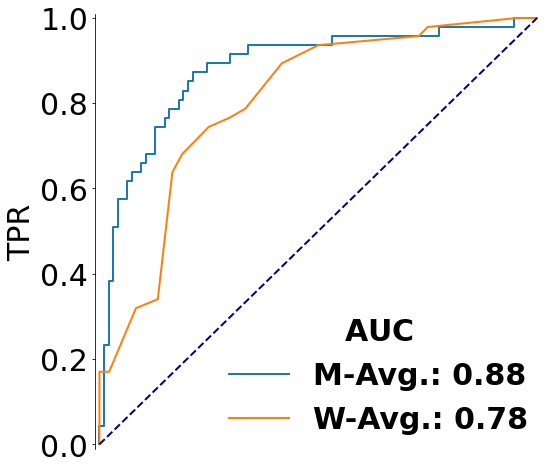

DSS 
 [0. 1.]


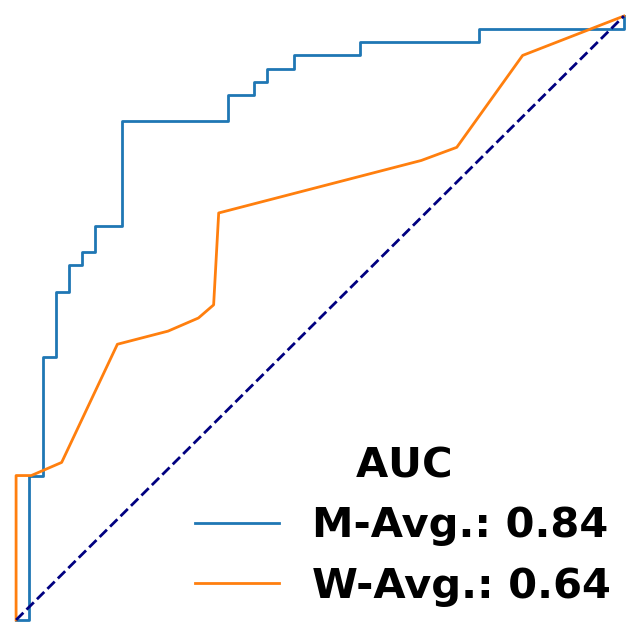

msi_status 
 ['Indeterminate' 'MSI-H' 'MSI-L' 'MSS']


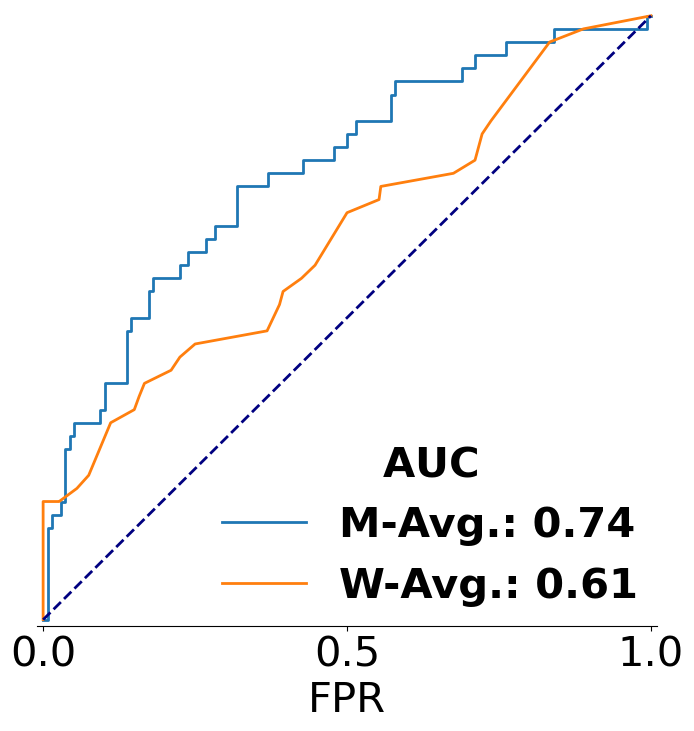

initial_pathologic_dx_year 
 ['High' 'Low' 'Moderate']


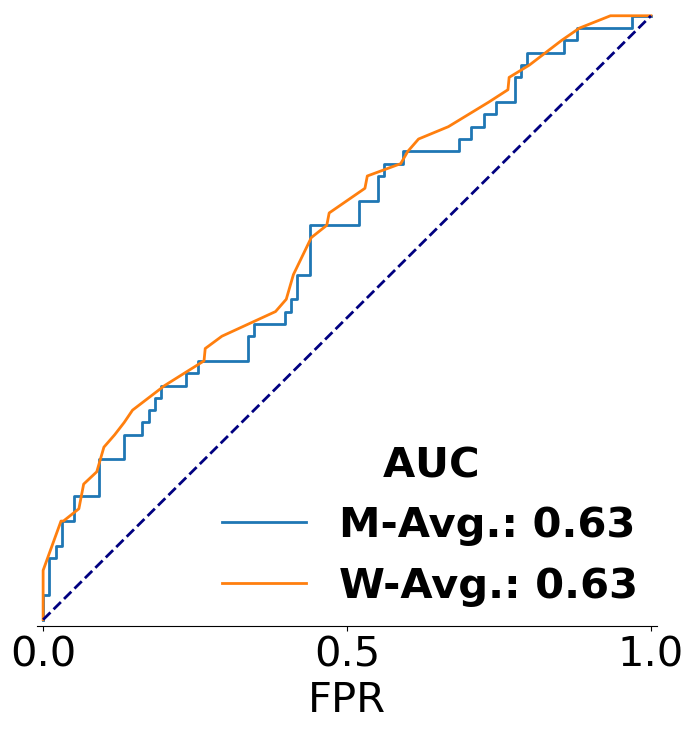

Proliferation 
 ['High' 'Low' 'Moderate']


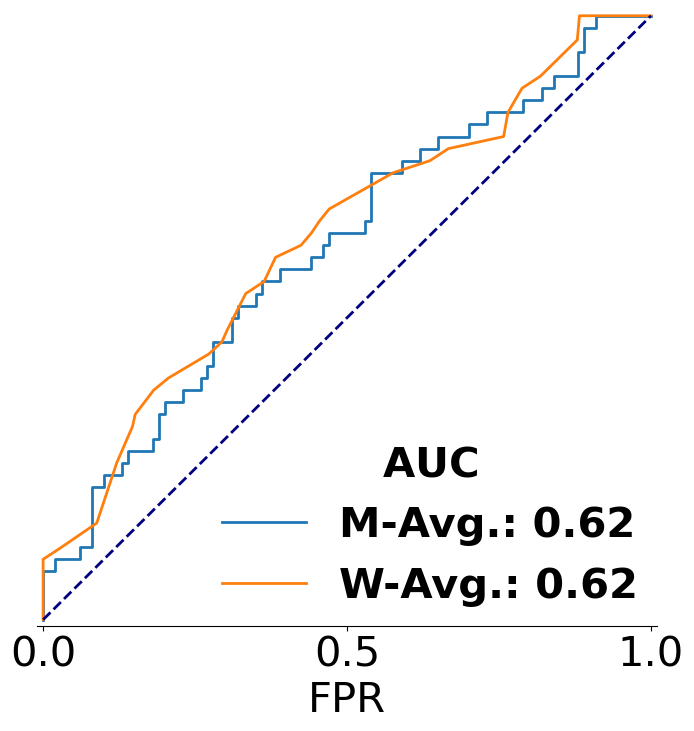

Number of Segments 
 ['High' 'Low' 'Moderate']


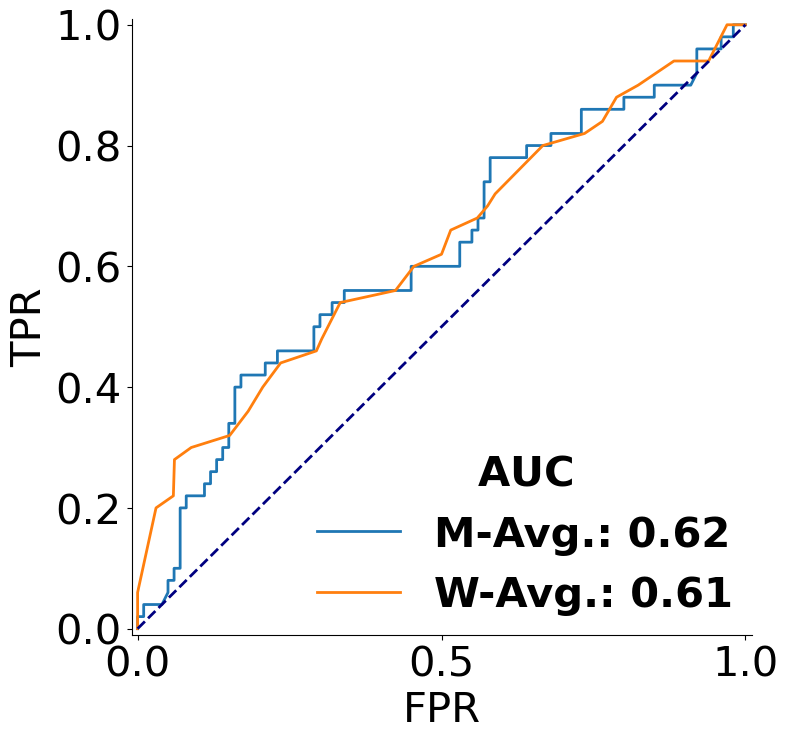

CTA Score 
 ['High' 'Low' 'Moderate']


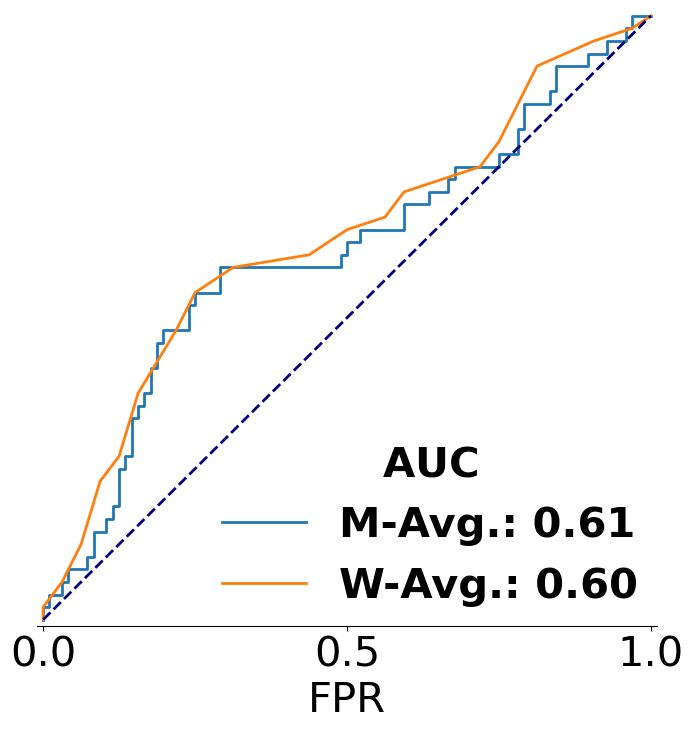

STAD
ethnicity 
 ['hispanic or latino' 'not hispanic or latino']


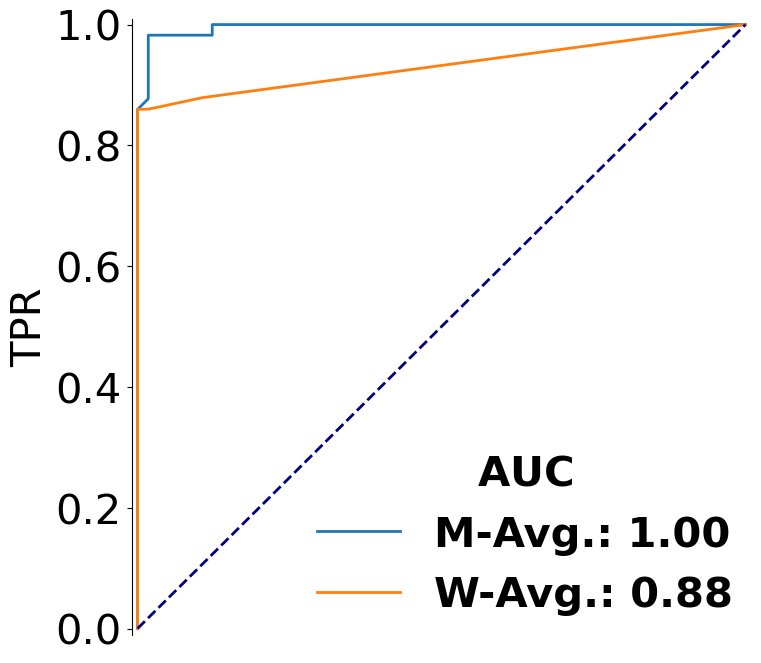

race 
 ['ASIAN' 'BLACK OR AFRICAN AMERICAN' 'WHITE']


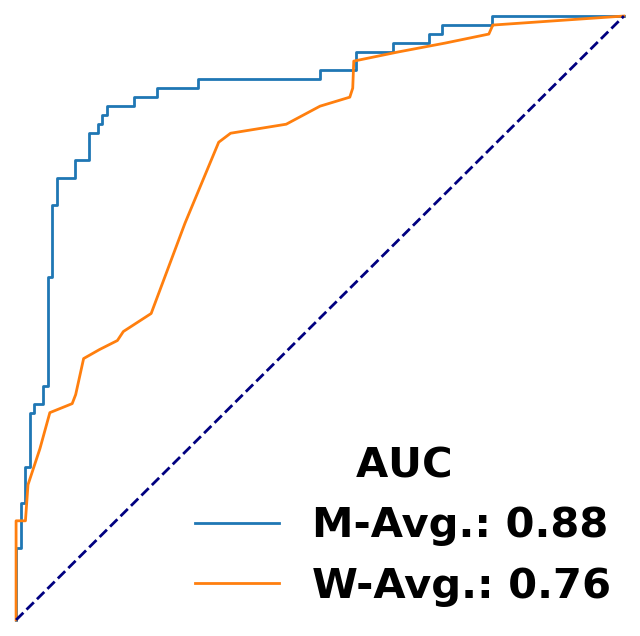

treatment_outcome_first_course 
 ['Complete Remission/Response' 'Progressive Disease' 'Stable Disease']


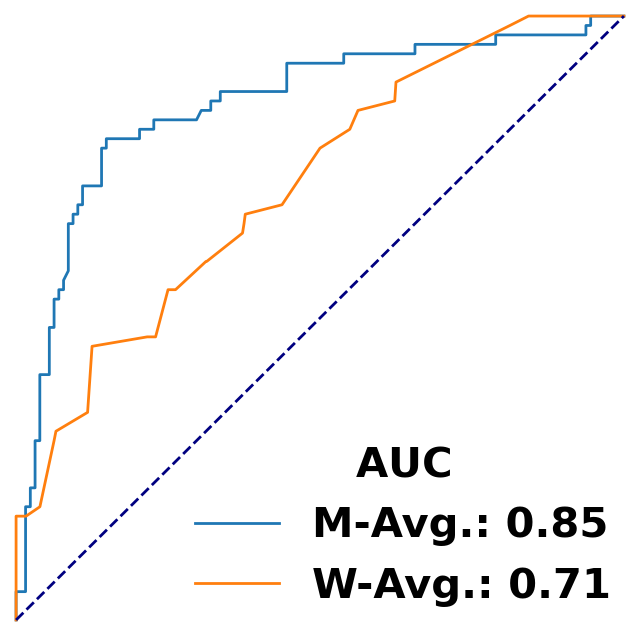

initial_pathologic_dx_year 
 ['High' 'Low' 'Moderate']


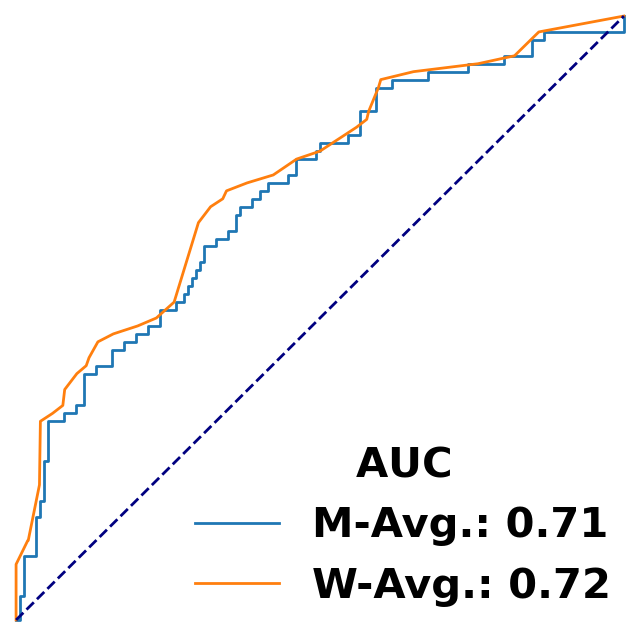

DSS 
 [0. 1.]


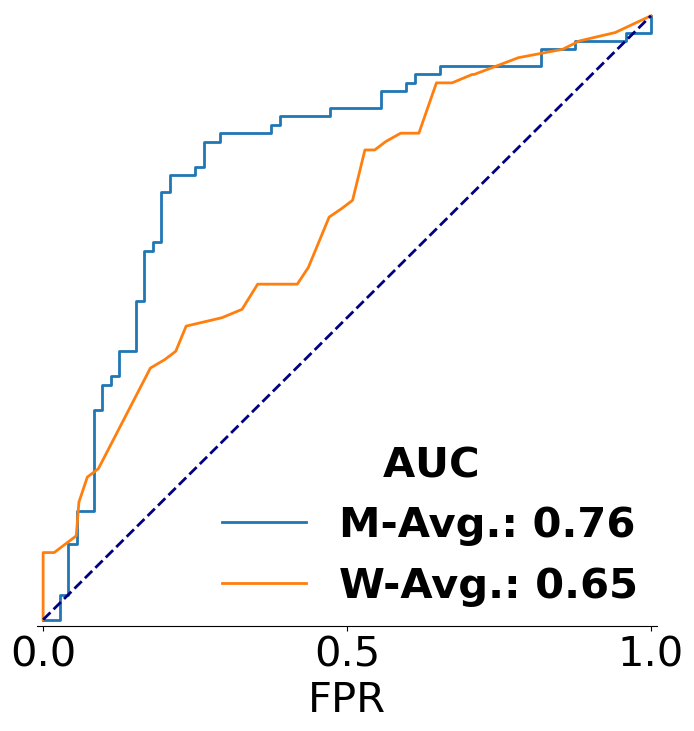

radiation_therapy 
 ['no' 'yes']


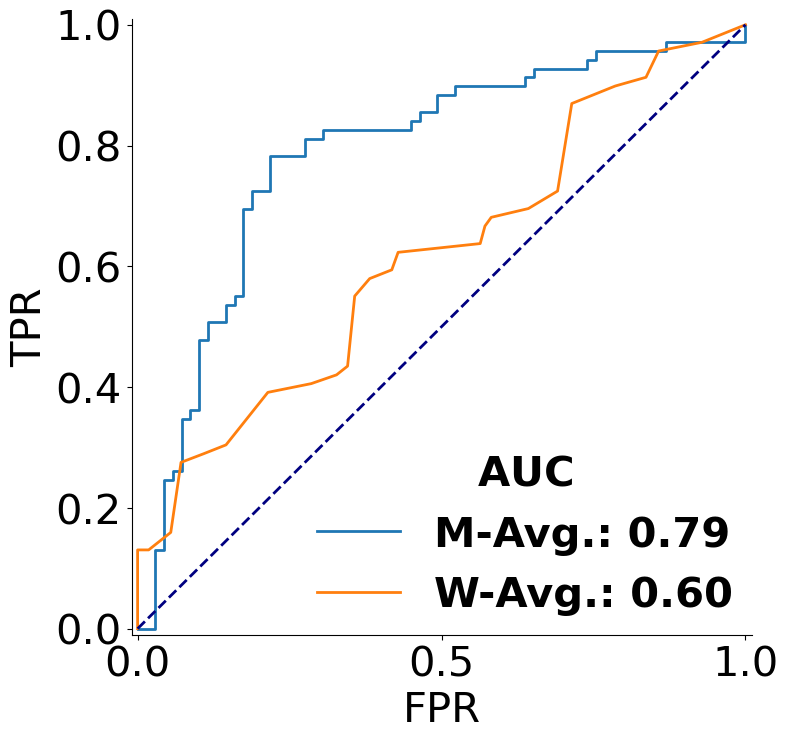

Number of Segments 
 ['High' 'Low' 'Moderate']


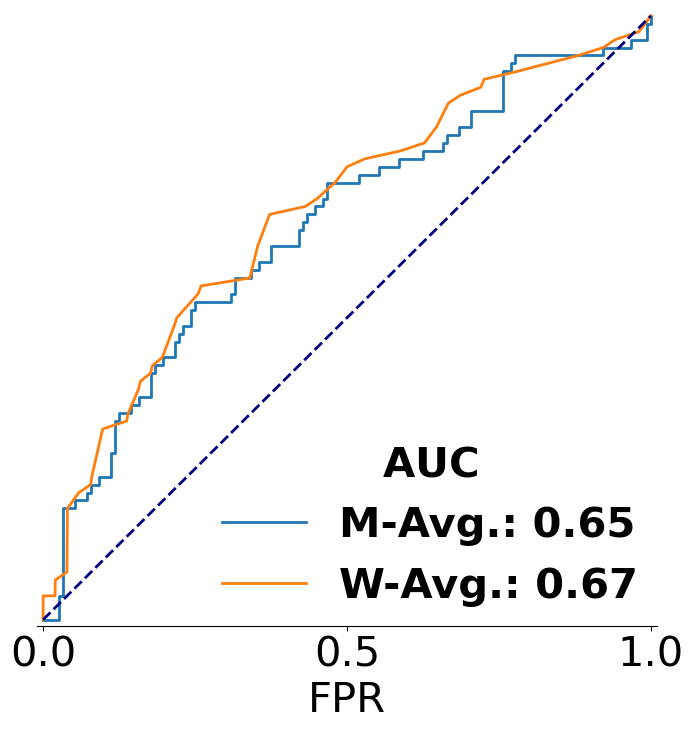

PFI 
 [0. 1.]


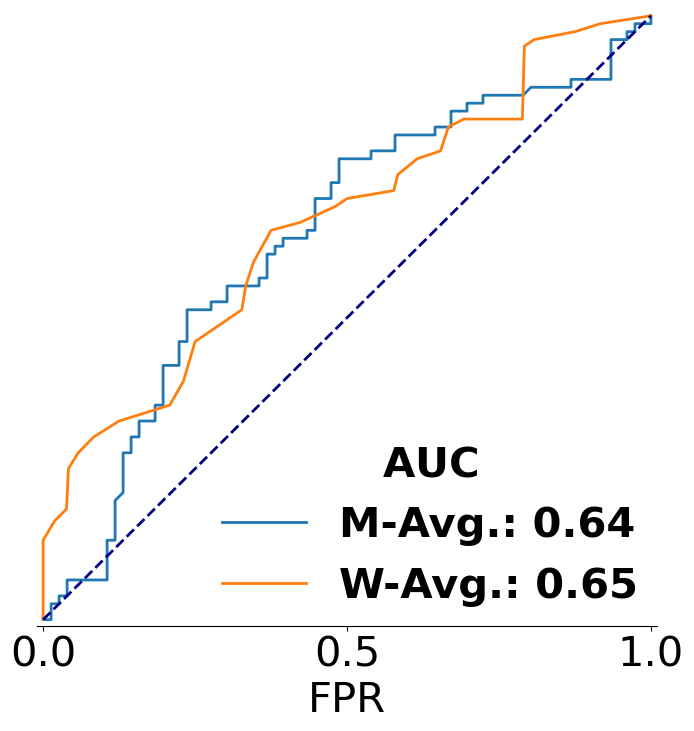

Wound Healing 
 ['High' 'Low' 'Moderate']


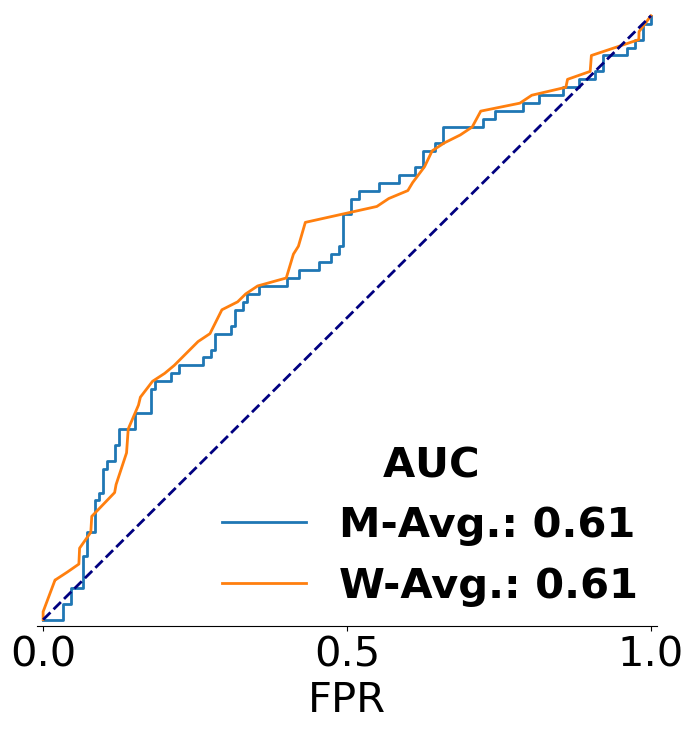

In [43]:
for CANCER in ['COAD', 'STAD']:
    print('=================================')
    print(CANCER)
    print('=================================')
    roc_curve_all(disease=CANCER, plot_axis='default')

### For website "x1y1"

race 
 ['ASIAN' 'BLACK OR AFRICAN AMERICAN' 'WHITE']


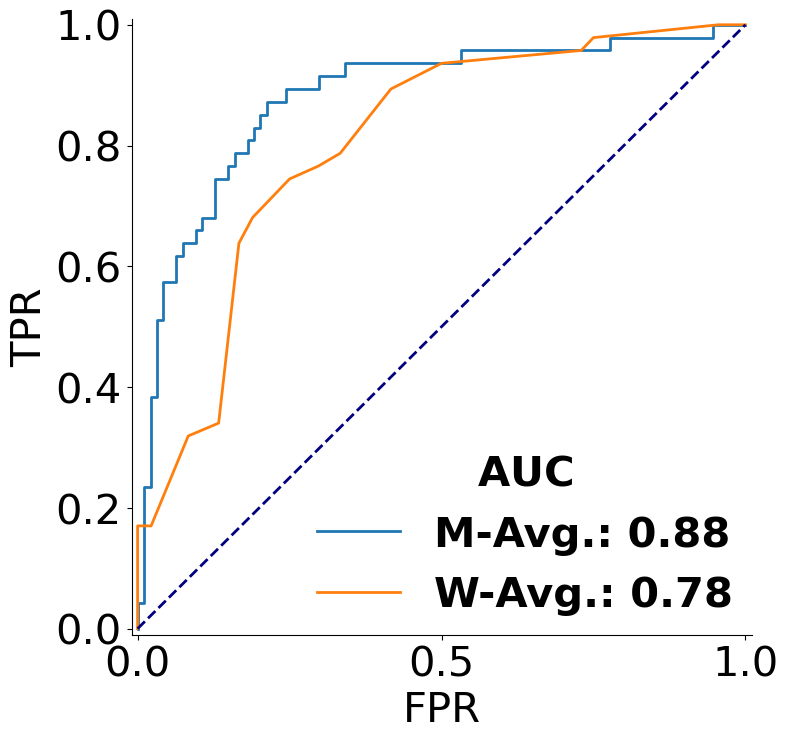

DSS 
 [0. 1.]


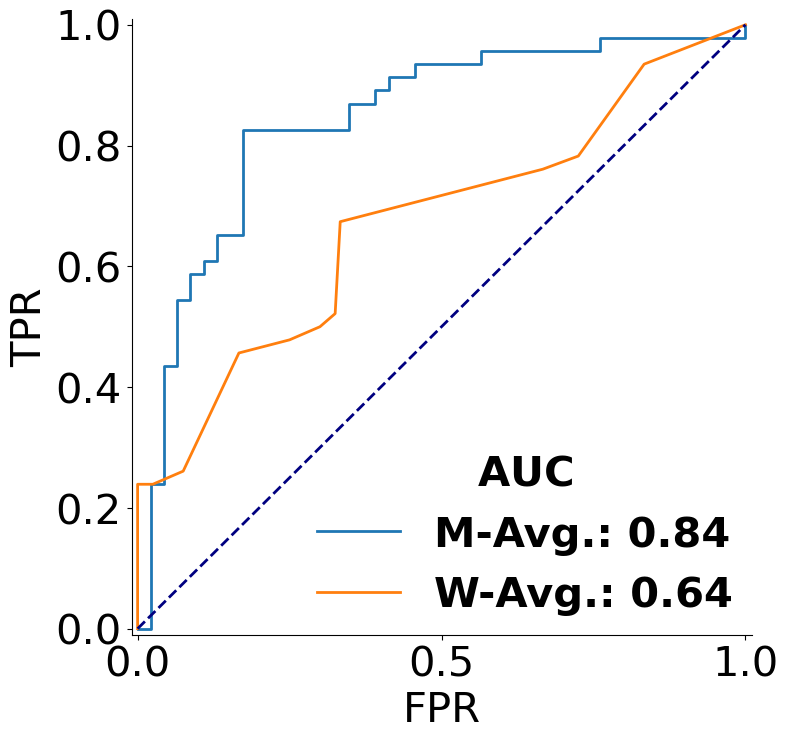

msi_status 
 ['Indeterminate' 'MSI-H' 'MSI-L' 'MSS']


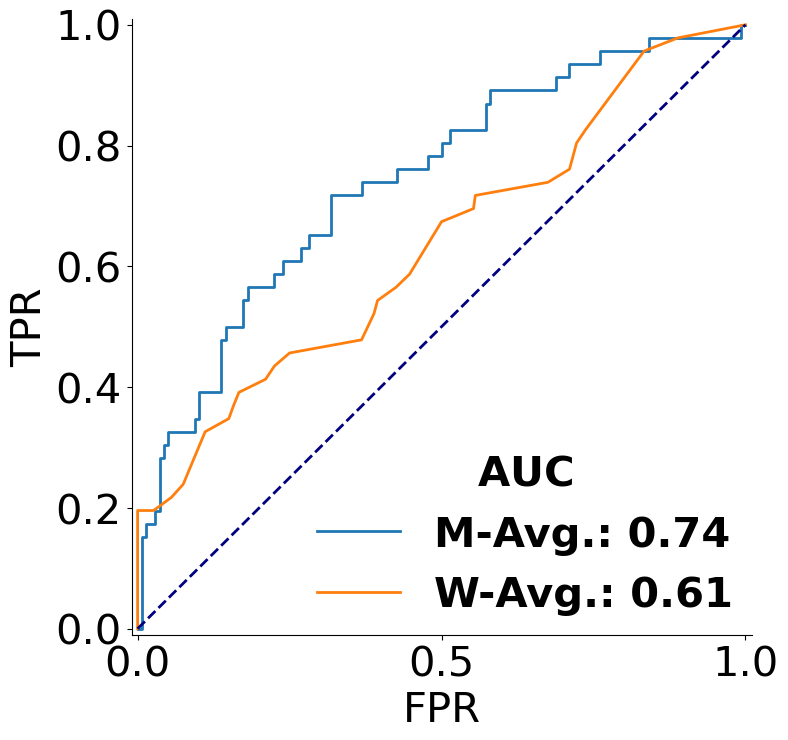

initial_pathologic_dx_year 
 ['High' 'Low' 'Moderate']


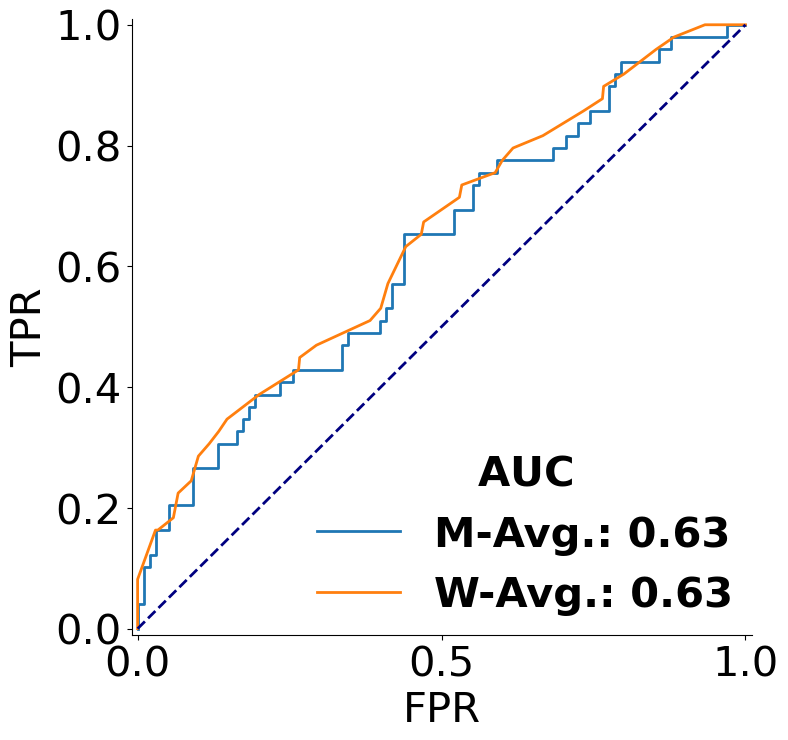

Proliferation 
 ['High' 'Low' 'Moderate']


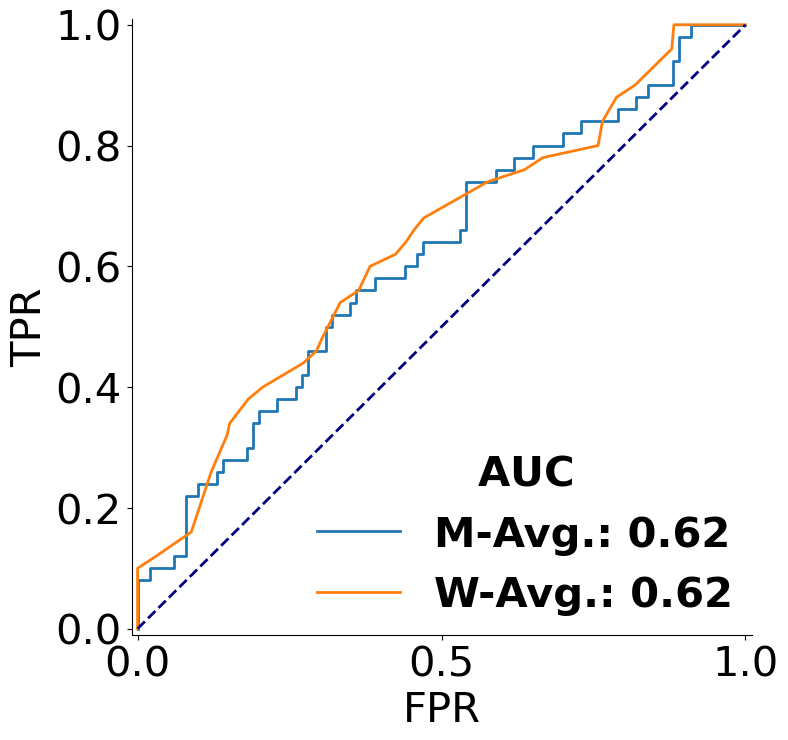

Number of Segments 
 ['High' 'Low' 'Moderate']


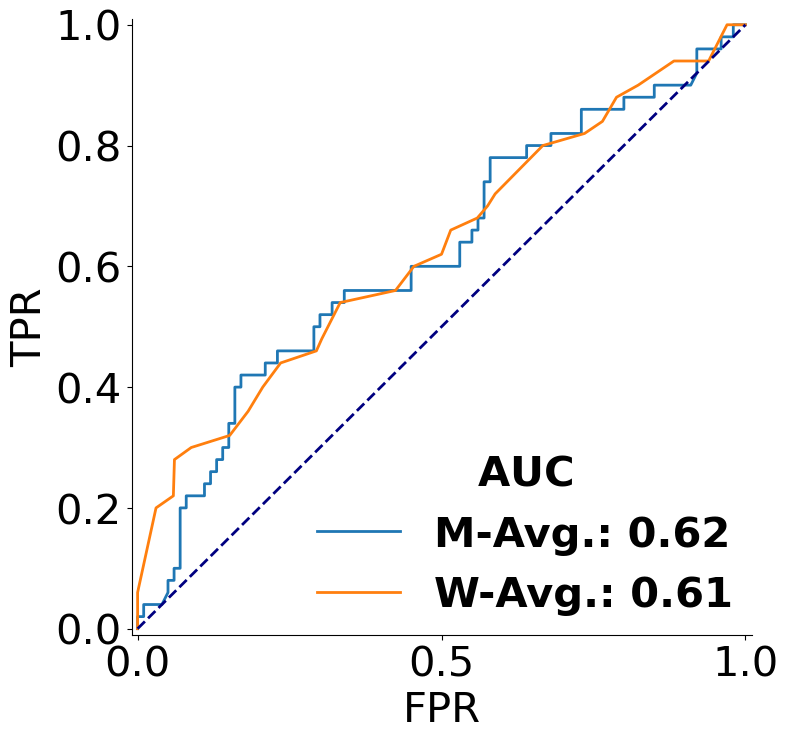

CTA Score 
 ['High' 'Low' 'Moderate']


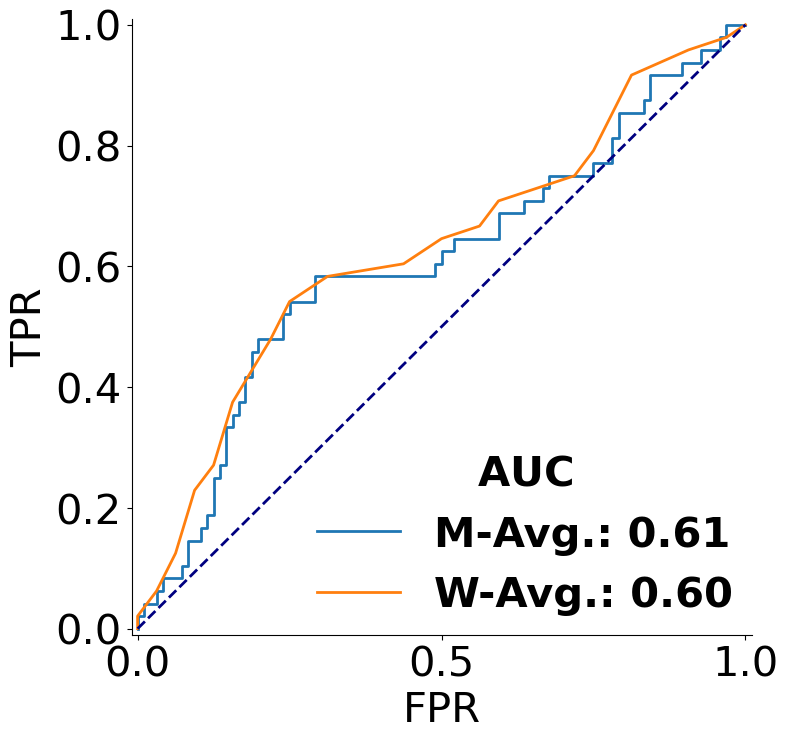

ethnicity 
 ['hispanic or latino' 'not hispanic or latino']


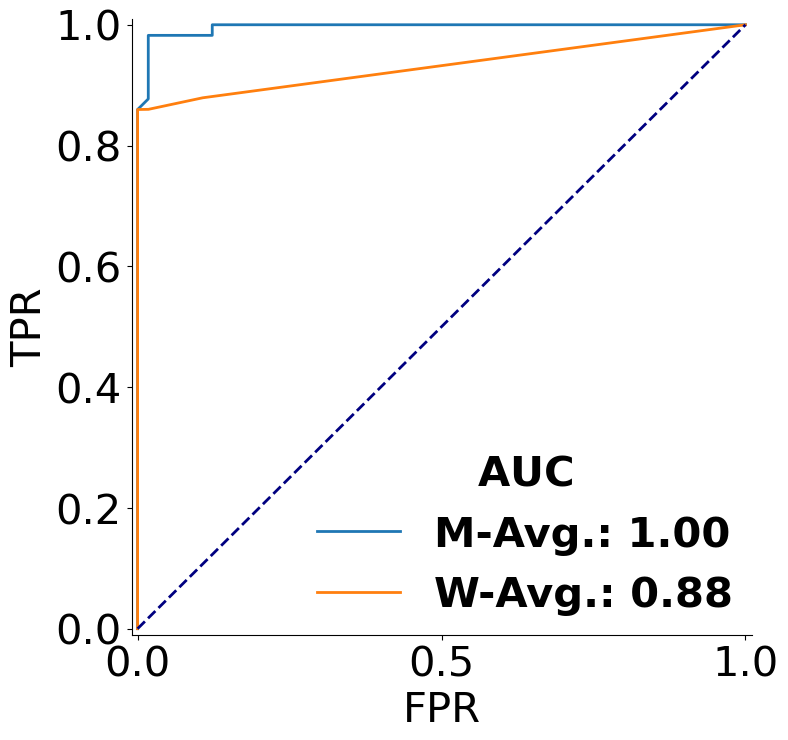

race 
 ['ASIAN' 'BLACK OR AFRICAN AMERICAN' 'WHITE']


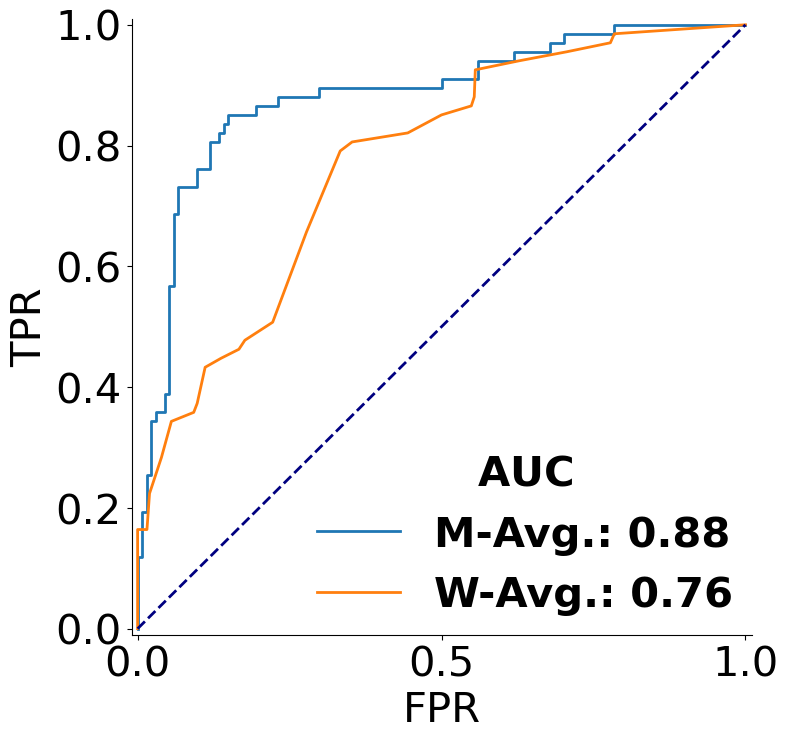

treatment_outcome_first_course 
 ['Complete Remission/Response' 'Progressive Disease' 'Stable Disease']


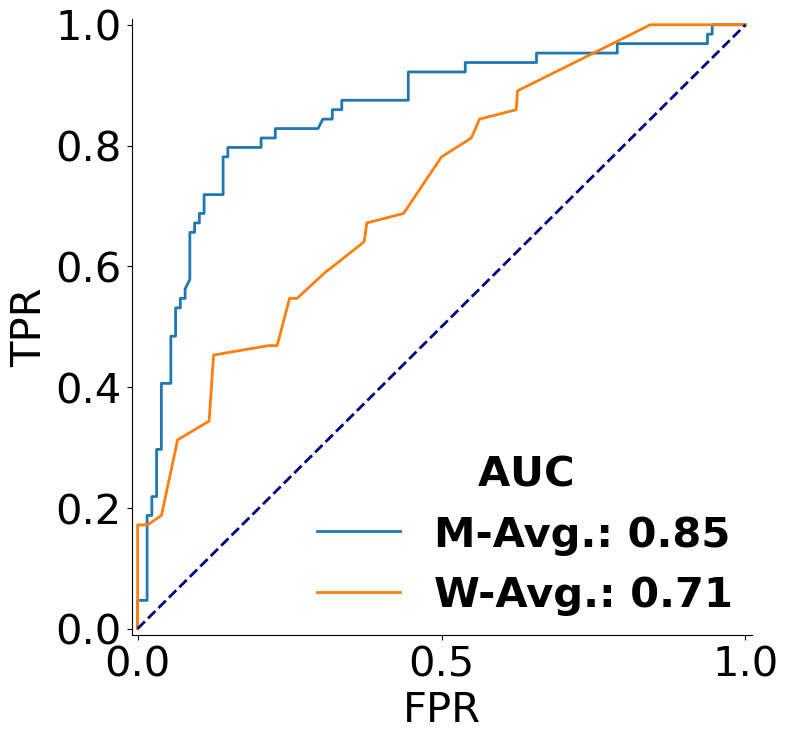

initial_pathologic_dx_year 
 ['High' 'Low' 'Moderate']


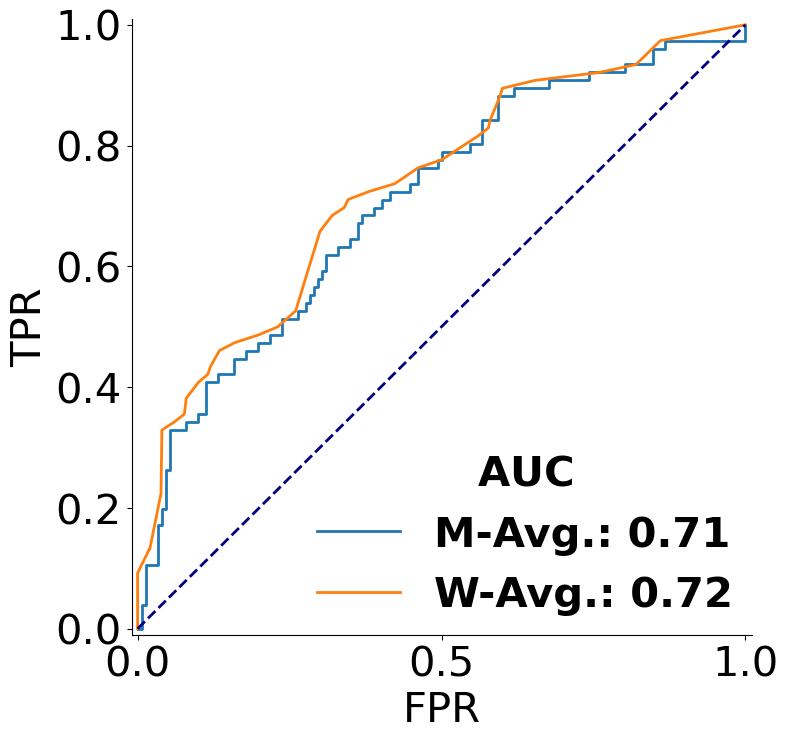

DSS 
 [0. 1.]


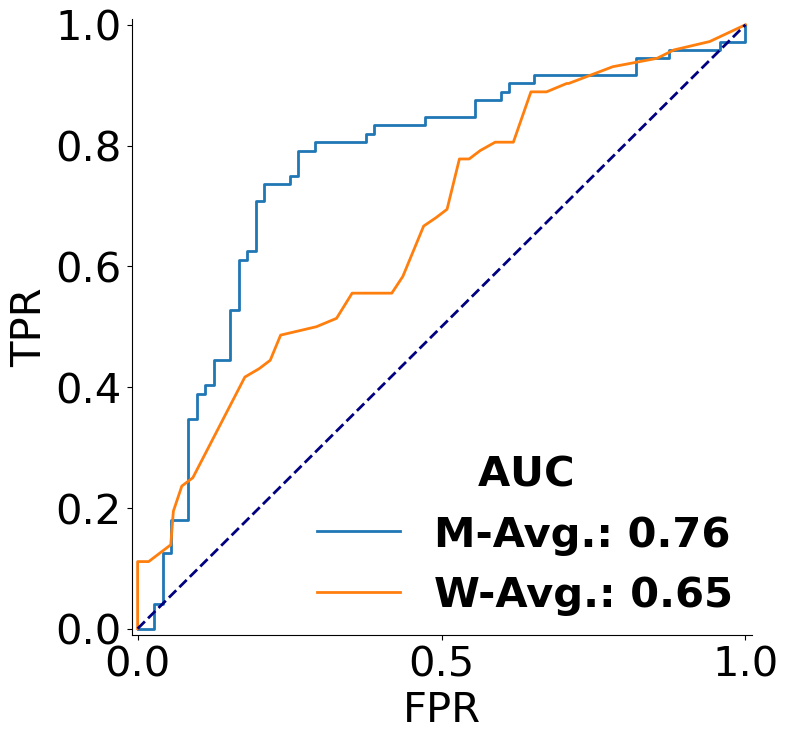

radiation_therapy 
 ['no' 'yes']


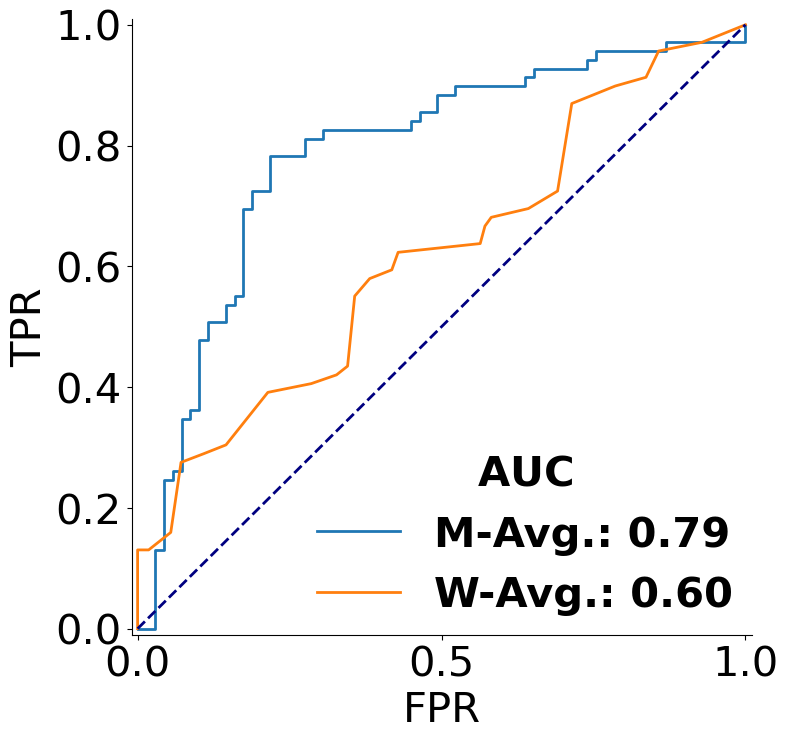

Number of Segments 
 ['High' 'Low' 'Moderate']


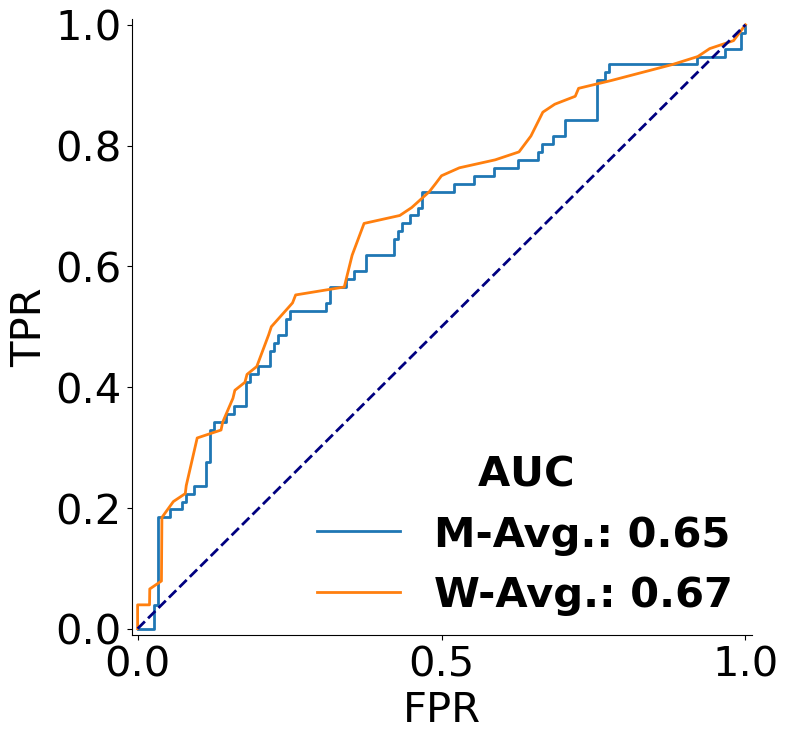

PFI 
 [0. 1.]


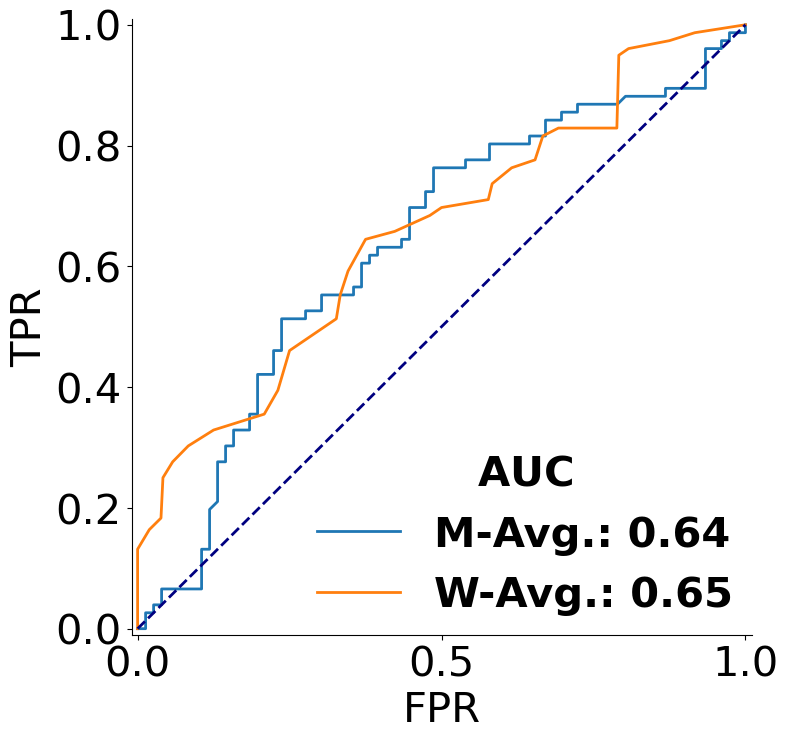

Wound Healing 
 ['High' 'Low' 'Moderate']


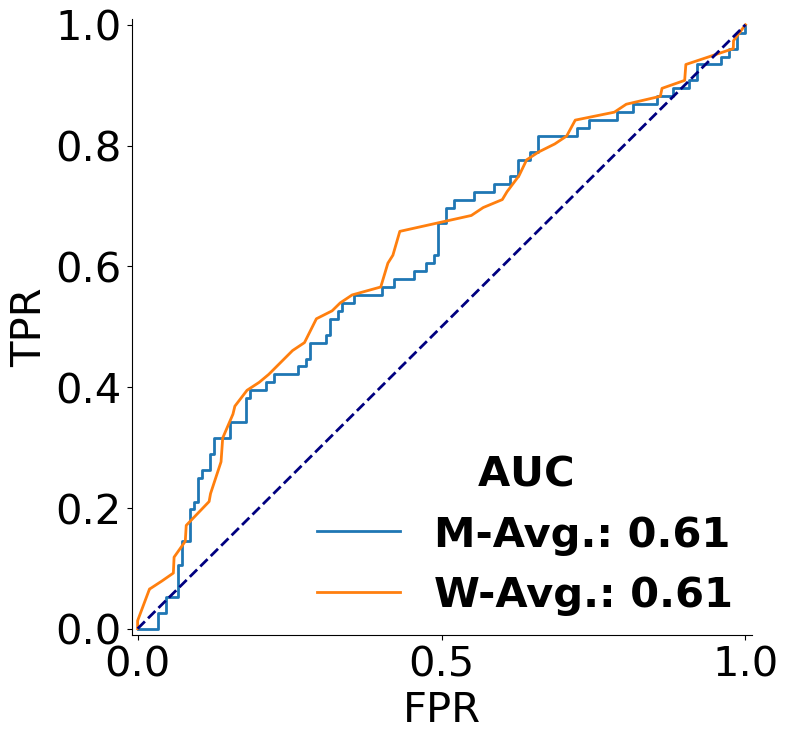

race 
 ['ASIAN' 'BLACK OR AFRICAN AMERICAN' 'WHITE']


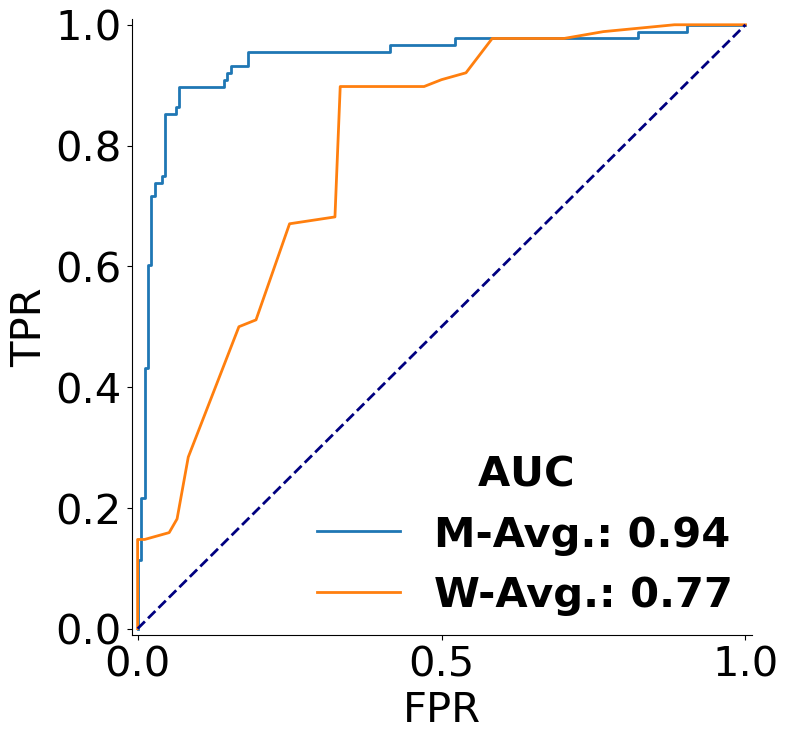

DSS 
 [0. 1.]


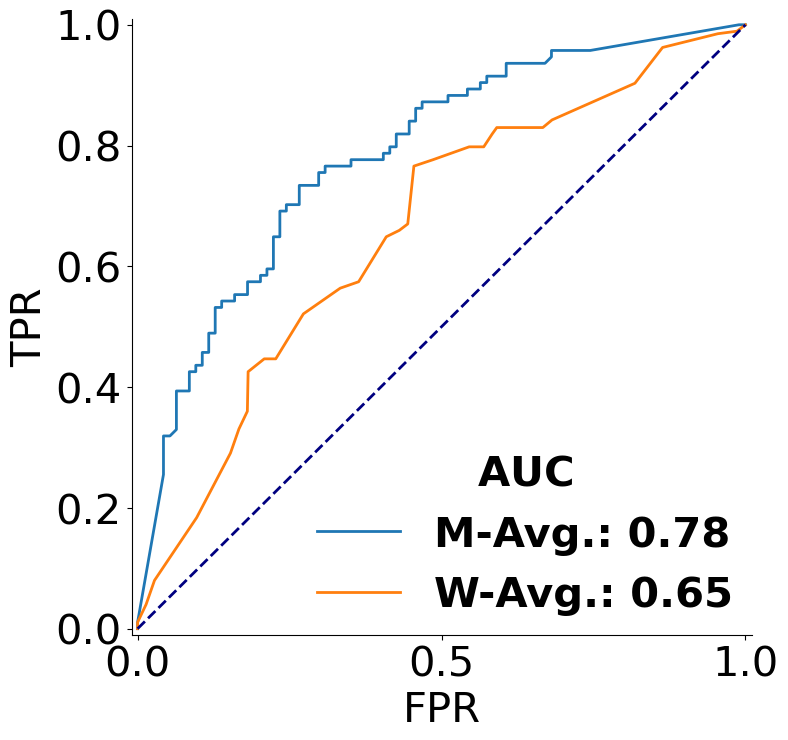

initial_pathologic_dx_year 
 ['High' 'Low' 'Moderate']


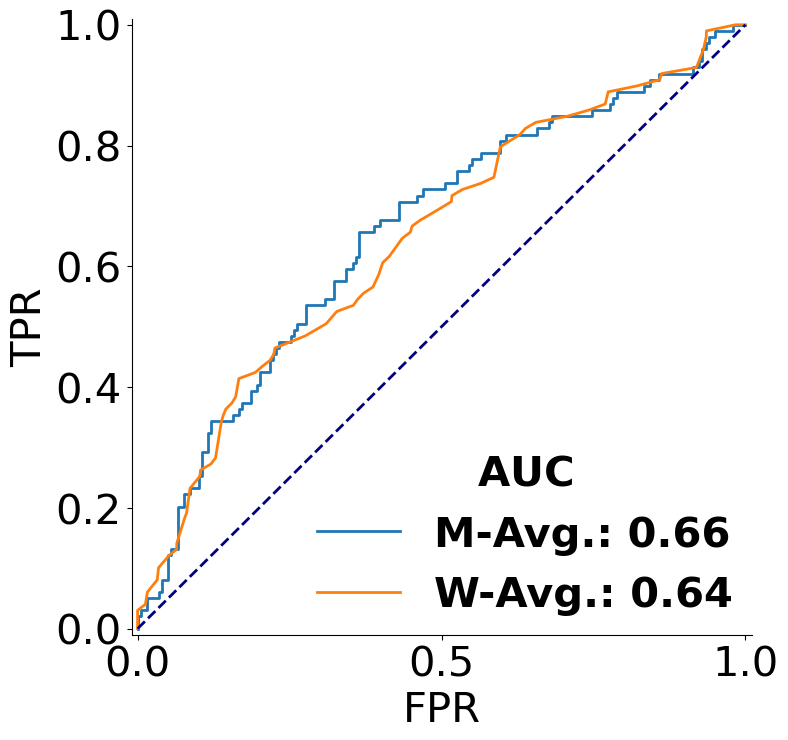

vital_status 
 ['Alive' 'Dead']


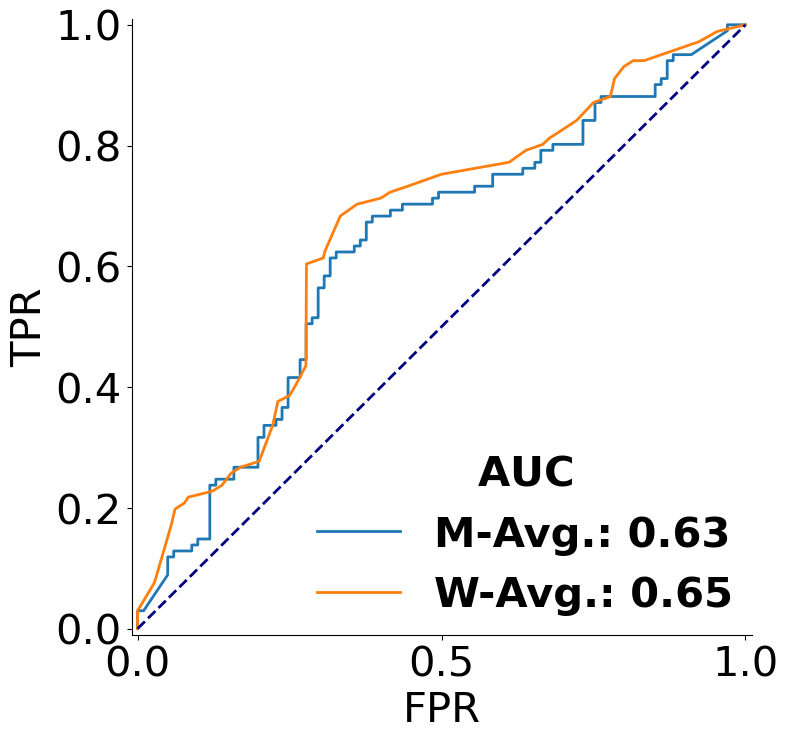

OS (dead=1) 
 [0. 1.]


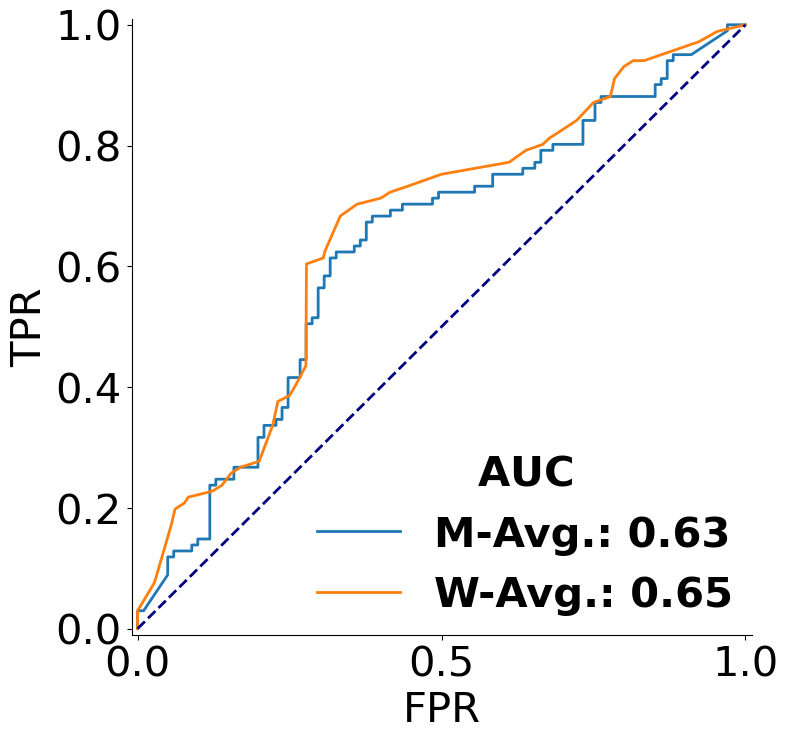

Proliferation 
 ['High' 'Low' 'Moderate']


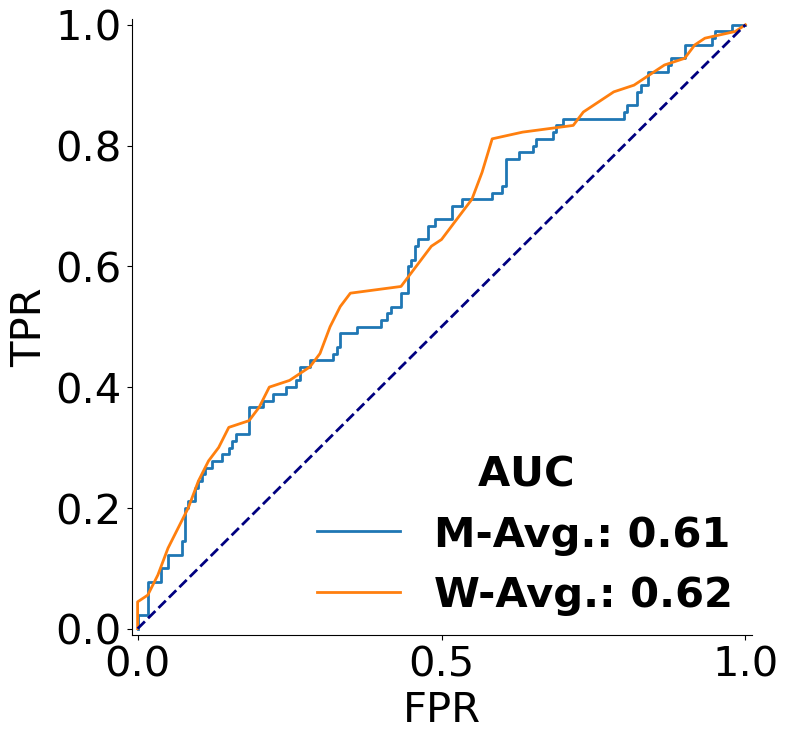

treatment_outcome_first_course 
 ['Complete Remission/Response' 'Progressive Disease' 'Stable Disease']


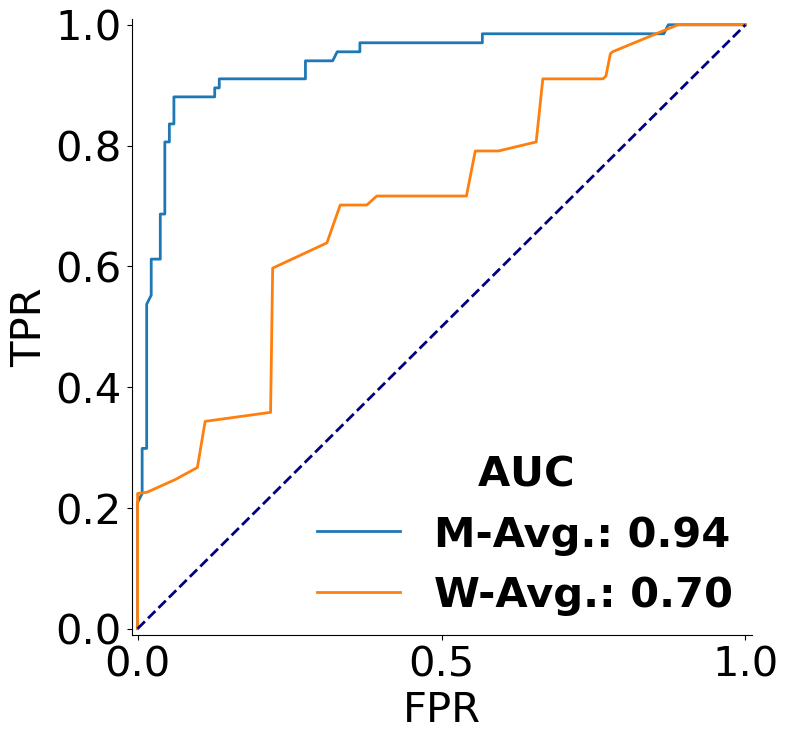

ethnicity 
 ['hispanic or latino' 'not hispanic or latino']


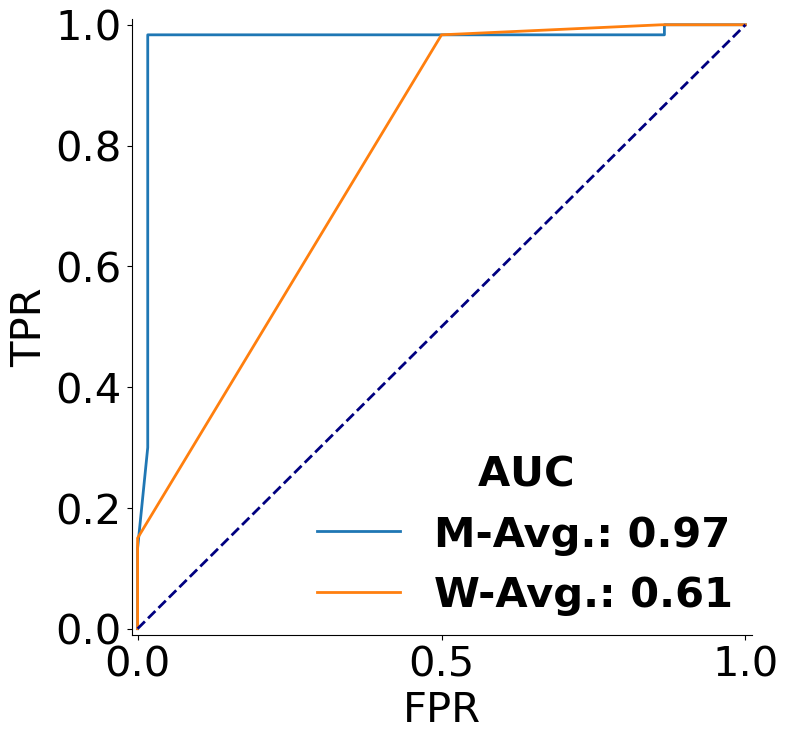

race 
 ['ASIAN' 'BLACK OR AFRICAN AMERICAN' 'WHITE']


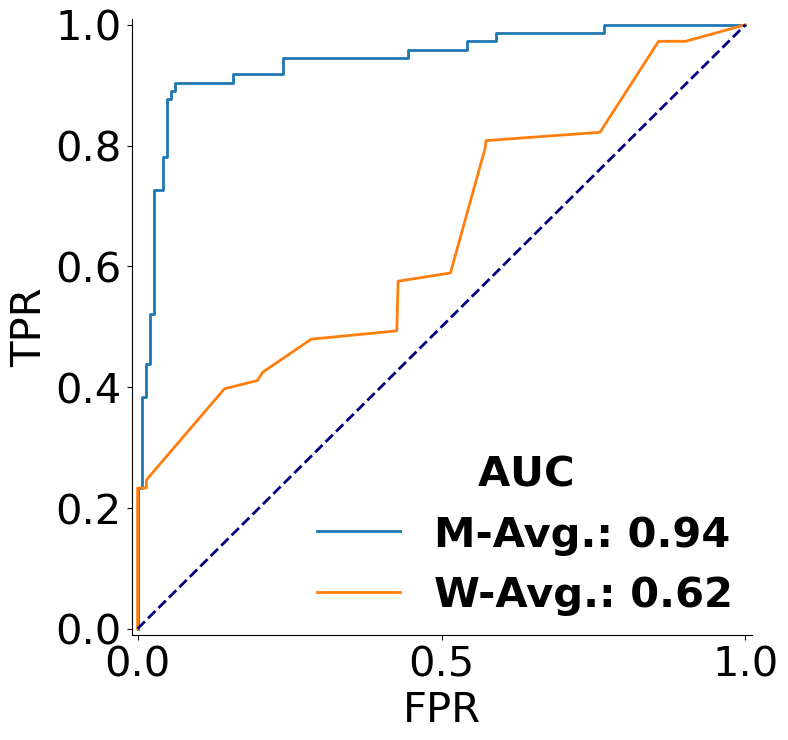

radiation_therapy 
 ['no' 'yes']


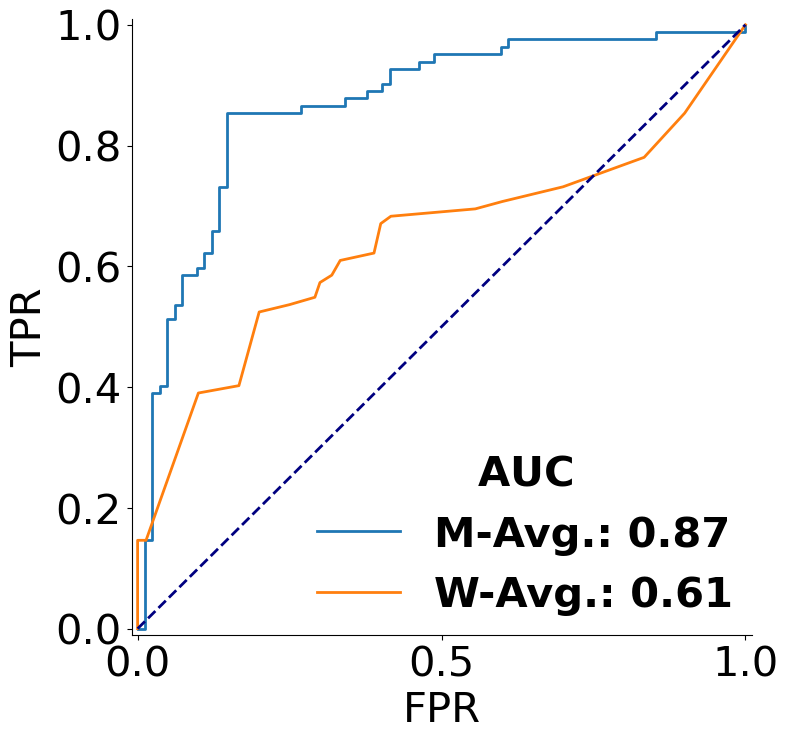

initial_pathologic_dx_year 
 ['High' 'Low' 'Moderate']


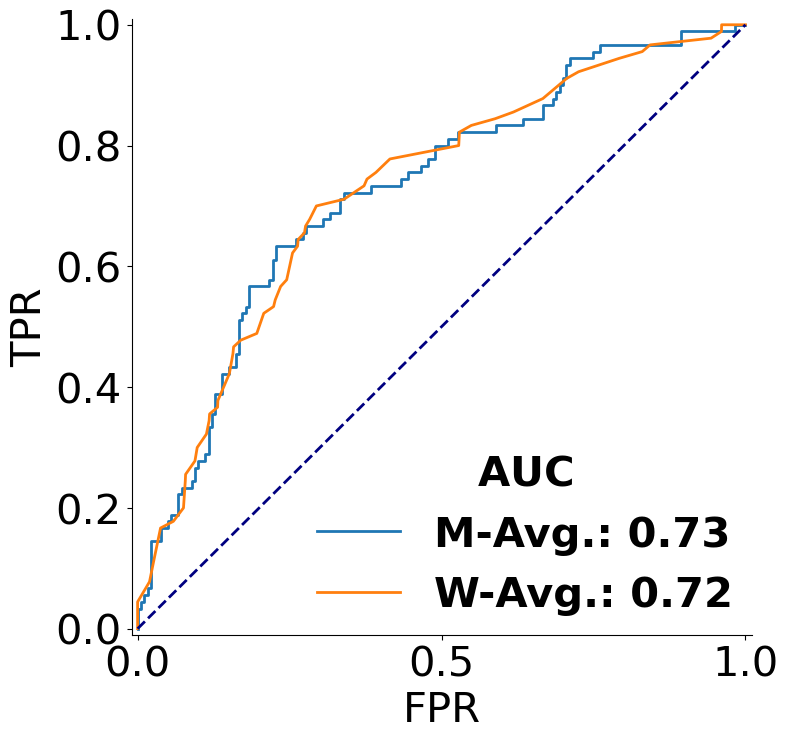

Stromal Fraction 
 ['High' 'Low' 'Moderate']


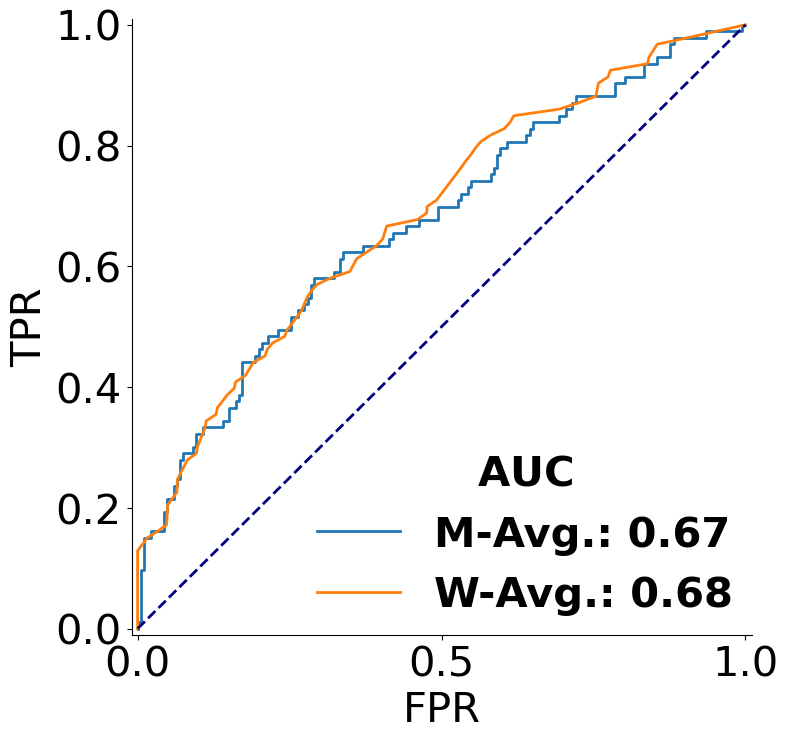

tumor_status 
 ['TUMOR FREE' 'WITH TUMOR']


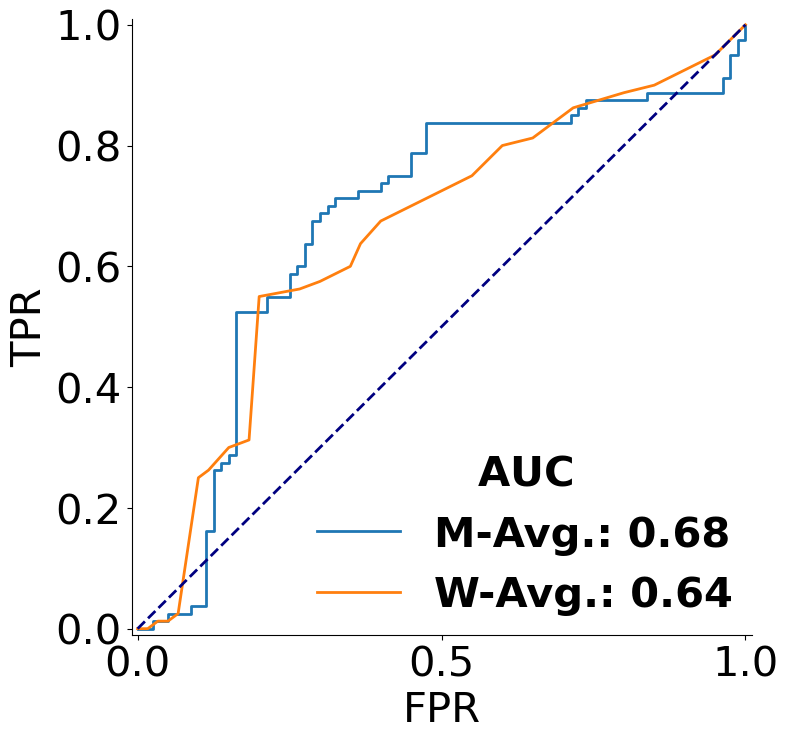

DFI.time (days) 
 ['High' 'Low' 'Moderate']


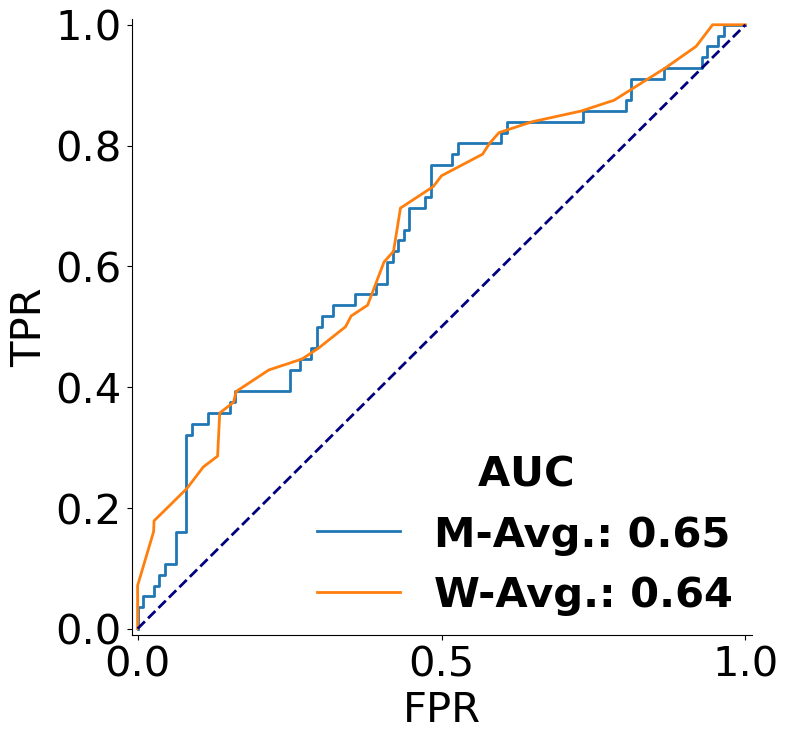

Proliferation 
 ['High' 'Low' 'Moderate']


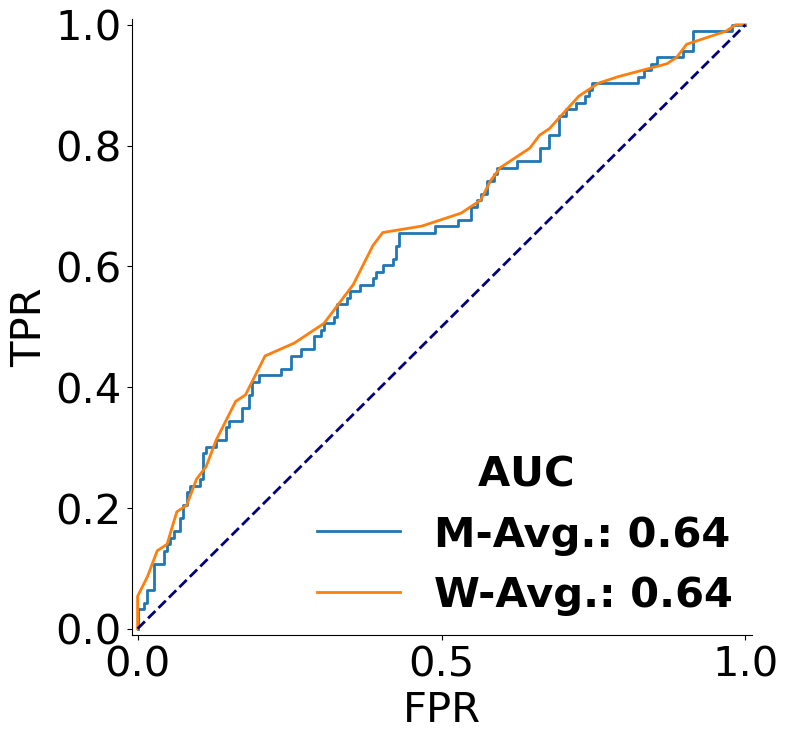

Wound Healing 
 ['High' 'Low' 'Moderate']


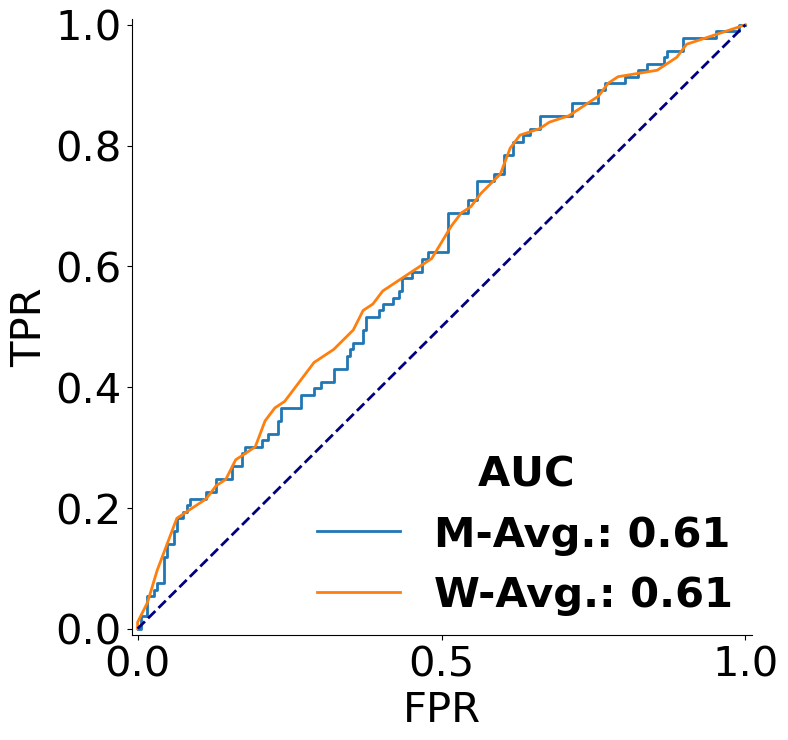

In [44]:
roc_curve_all(disease='COAD', fig_save_folder='./figures/web_ROC', plot_axis='x1y1', save_format='png')
roc_curve_all(disease='STAD', fig_save_folder='./figures/web_ROC', plot_axis='x1y1', save_format='png')
roc_curve_all(disease='LUAD', fig_save_folder='./figures/web_ROC', plot_axis='x1y1', save_format='png')
roc_curve_all(disease='LUSC', fig_save_folder='./figures/web_ROC', plot_axis='x1y1', save_format='png')

---

## Heatmap

In [11]:
def sort_influence(disease, save_folder='./', decreasing=True, covariate_list=None):
    with open(os.path.join(save_folder, f'results/LRP/{disease}/lrp_result_dict.pkl'), "rb") as f:
        lrp_result_dict = CPU_Unpickler(f).load()
    influence = lrp_result_dict['influence_by_microbe_all']
    row_names = lrp_result_dict['y_col_names'] if covariate_list is None else covariate_list
    column_names = pd.read_pickle(os.path.join(save_folder, 
                                               f'data/processed data/{disease}_microbiome_clean.pkl')).columns
    column_names = np.array([name.split('-')[0] for name in column_names])
    ### Sorted by col sum
    ascending_sort_idx_col = np.argsort(np.sum(influence, axis=0))
    sort_idx_col = ascending_sort_idx_col[::-1] if decreasing else ascending_sort_idx_col
    ### Sorted row by AUC scores
    sorted_auc_df = sorted_auc(disease, print_disease_name=False)
    sort_idx_row = np.array([np.where(rn == row_names)[0][0] for rn in sorted_auc_df['Covariate']])
    sorted_influence_df = pd.DataFrame(influence[sort_idx_row,:][:, sort_idx_col], 
                                columns = column_names[sort_idx_col], 
                                index = sorted_auc_df['Covariate'].values)
    return sorted_influence_df

In [46]:
def heatmap_influence(
    disease,
    influence_df,
    top_col_pct=0.05,
    plot=True,
    covariate_subset=None,
    cmap="Blues",
    cbar=True,
    cmax=None,
    taxa_names=True,
    feature_names=True,
    fontsize=16,
    row_label_fontsize=None,
    col_label_fontsize=None,
    anno_label_fontsize=None,
    colorbar_tick_fontsize=None,
    font_scale=2.5,
    linewidths=0.,
    horizontal=True,
    save=False,
    fig_save_folder='./figures',
    add_ecology_bar=False,
    ecology_file="../data/bacdive_genus_ecology_labels.csv"
):

    import os
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap, BoundaryNorm
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    genus_name = list(influence_df.columns)
    nona_idx = np.where(np.array(genus_name) != '')[0]
    genus_name_nona = np.array(genus_name)[nona_idx]

    influence_df_genus_lvl = influence_df.iloc[:, nona_idx]
    influence_df_genus_lvl.columns = list(genus_name_nona)

    n_col_selected = np.round(influence_df_genus_lvl.shape[1] * top_col_pct).astype(int)
    n_col_selected = max(n_col_selected, 1)

    if covariate_subset is None:
        row_subset = influence_df_genus_lvl.index
    else:
        row_subset = covariate_subset

    influence_df_genus_lvl_marker = influence_df_genus_lvl.loc[
        row_subset, influence_df_genus_lvl.columns[:n_col_selected]
    ]

    if top_col_pct == 1.:
        influence_df_genus_lvl_marker.to_csv(f'./results/LRP/{disease}/sorted_influence_df.csv')
    else:
        influence_df_genus_lvl_marker.to_csv(
            f'./results/LRP/{disease}/sorted_influence_df_pct{str(int(top_col_pct*100))}.csv'
        )

    if plot:
        sns.set(font_scale=font_scale)

        if horizontal:
            figheight = len(row_subset) * 2 - 2
            figwidth = n_col_selected * 2
            fig, ax = plt.subplots(figsize=(figwidth, figheight))

            hm = sns.heatmap(
                influence_df_genus_lvl_marker,
                linewidths=linewidths,
                cbar=cbar,
                cbar_kws={"pad": 0.01},
                cmap=cmap,
                vmin=0,
                vmax=cmax,
                ax=ax
            )

            row_fs = row_label_fontsize if row_label_fontsize is not None else fontsize
            col_fs = col_label_fontsize if col_label_fontsize is not None else fontsize
            cbar_fs = colorbar_tick_fontsize if colorbar_tick_fontsize is not None else max(10, int(fontsize * 0.6))

            if taxa_names:
                hm.set_xticklabels(
                    hm.get_xticklabels(),
                    rotation=45,
                    ha='left',
                    rotation_mode='anchor',
                    fontsize=col_fs
                )
            else:
                hm.set_xticklabels([])

            if feature_names:
                hm.set_yticklabels(
                    hm.get_yticklabels(),
                    fontsize=row_fs,
                    rotation=0,
                    ha='right'
                )
            else:
                hm.set_yticklabels([])

            ax.tick_params(top=False, labelbottom=False, labeltop=True)

            if cbar:
                cb = hm.collections[0].colorbar
                cb.ax.tick_params(labelsize=cbar_fs)

        else:
            label_display_map = {
                "highly_likely_environmental": "Highly likely environmental",
                "could_be_environmental": "Could be environmental",
                "highly_likely_host_associated": "Highly likely host-associated",
                "likely_host_associated": "Likely host-associated",
                "mixed_or_uncertain": "Mixed or uncertain",
                "no_data": "No BacDive data"
            }

            label_abbrev_map = {
                "Highly likely environmental": "HE",
                "Could be environmental": "CE",
                "Highly likely host-associated": "HH",
                "Likely host-associated": "LH",
                "Mixed or uncertain": "MU",
                "No BacDive data": "NA"
            }

            label_color_map = {
                "Highly likely environmental": "#f8d7da",
                "Could be environmental": "#fde2c8",
                "Highly likely host-associated": "#8fd19e",
                "Likely host-associated": "#dff3e3",
                "Mixed or uncertain": "#e9ecef",
                "No BacDive data": "#f5f5f5"
            }

            label_text_color_map = {
                "Highly likely environmental": "#721c24",
                "Could be environmental": "#8a4b08",
                "Highly likely host-associated": "#0f5132",
                "Likely host-associated": "#2b6e3f",
                "Mixed or uncertain": "#495057",
                "No BacDive data": "#6c757d"
            }

            label_fontstyle_map = {
                "Highly likely environmental": "normal",
                "Could be environmental": "normal",
                "Highly likely host-associated": "normal",
                "Likely host-associated": "normal",
                "Mixed or uncertain": "normal",
                "No BacDive data": "italic"
            }

            label_fontweight_map = {
                "Highly likely environmental": "bold",
                "Could be environmental": "bold",
                "Highly likely host-associated": "bold",
                "Likely host-associated": "bold",
                "Mixed or uncertain": "bold",
                "No BacDive data": "normal"
            }

            taxa_order = list(influence_df_genus_lvl_marker.T.index)
            feature_order = list(influence_df_genus_lvl_marker.T.columns)
            n_taxa = len(taxa_order)
            n_features = len(feature_order)

            ecology_labels = {g: "No BacDive data" for g in taxa_order}
            if add_ecology_bar:
                eco_df = pd.read_csv(ecology_file)
                eco_df["Genus"] = eco_df["Genus"].astype(str).str.strip()
                eco_df["label"] = eco_df["label"].astype(str).str.strip()
                eco_df["display_label"] = eco_df["label"].map(label_display_map)
                eco_df["display_label"] = eco_df["display_label"].fillna("No BacDive data")
                eco_map = dict(zip(eco_df["Genus"], eco_df["display_label"]))
                for g in taxa_order:
                    if g in eco_map:
                        ecology_labels[g] = eco_map[g]

            cell_w = 0.55
            cell_h = 0.36
            figwidth = max(8, n_features * cell_w + 4.8)
            figheight = max(10, n_taxa * cell_h + 2.2)

            fig, ax = plt.subplots(figsize=(figwidth, figheight))

            hm = sns.heatmap(
                influence_df_genus_lvl_marker.T,
                linewidths=linewidths,
                cbar=False,
                cmap=cmap,
                vmin=0,
                vmax=cmax,
                ax=ax,
                xticklabels=feature_names,
                yticklabels=False
            )

            ax.set_yticks([])
            ax.set_yticklabels([])
            ax.tick_params(axis='y', left=False, right=False, labelleft=False, labelright=False)

            col_fs = col_label_fontsize if col_label_fontsize is not None else min(fontsize, max(9, 180 / max(n_features, 1)))
            row_fs = row_label_fontsize if row_label_fontsize is not None else col_fs
            anno_fs = anno_label_fontsize if anno_label_fontsize is not None else min(fontsize - 4, max(7, 180 / max(n_taxa, 1)))
            cbar_fs = colorbar_tick_fontsize if colorbar_tick_fontsize is not None else max(10, int(fontsize * 0.6))
            col_rot = 30

            if feature_names:
                hm.set_xticklabels(
                    hm.get_xticklabels(),
                    fontsize=col_fs,
                    rotation=col_rot,
                    ha='left',
                    rotation_mode='anchor',
                    fontweight='normal'
                )
            else:
                hm.set_xticklabels([])

            ax.tick_params(top=False, labelbottom=False, labeltop=True, bottom=False)

            divider = make_axes_locatable(ax)

            if add_ecology_bar:
                anno_width_pct = 100.0 / max(n_features, 1)
                ax_anno = divider.append_axes(
                    "left",
                    size=f"{anno_width_pct}%",
                    pad=0.04,   # gap between annotation bar and heatmap
                    sharey=ax
                )

                ordered_display_labels = [
                    "Highly likely environmental",
                    "Could be environmental",
                    "Highly likely host-associated",
                    "Likely host-associated",
                    "Mixed or uncertain",
                    "No BacDive data"
                ]
                label_to_code = {lab: i for i, lab in enumerate(ordered_display_labels)}
                anno_codes = np.array(
                    [label_to_code[ecology_labels[g]] for g in taxa_order]
                ).reshape(-1, 1)

                anno_cmap = ListedColormap([label_color_map[lab] for lab in ordered_display_labels])
                anno_norm = BoundaryNorm(
                    np.arange(-0.5, len(ordered_display_labels) + 0.5, 1),
                    anno_cmap.N
                )

                sns.heatmap(
                    anno_codes,
                    ax=ax_anno,
                    cmap=anno_cmap,
                    norm=anno_norm,
                    cbar=False,
                    xticklabels=False,
                    yticklabels=False,
                    linewidths=linewidths,
                    linecolor="white"
                )

                ax_anno.set_ylim(ax.get_ylim())
                for spine in ax_anno.spines.values():
                    spine.set_visible(False)

                for i, genus in enumerate(taxa_order):
                    disp_label = ecology_labels.get(genus, "No BacDive data")
                    abbrev = label_abbrev_map[disp_label]
                    ax_anno.text(
                        0.5, i + 0.5, abbrev,
                        ha="center", va="center",
                        fontsize=anno_fs,
                        color=label_text_color_map[disp_label],
                        fontweight=label_fontweight_map[disp_label],
                        fontstyle=label_fontstyle_map[disp_label]
                    )

                ax_anno.set_yticks(np.arange(n_taxa) + 0.5)
                ax_anno.set_yticklabels(
                    taxa_order,
                    rotation=col_rot,
                    ha='right',
                    va='center',
                    rotation_mode='anchor',
                    fontsize=row_fs,
                    fontweight='normal'
                )
                ax_anno.yaxis.tick_left()
                ax_anno.tick_params(
                    axis='y',
                    left=False,
                    right=False,
                    labelleft=True,
                    labelright=False,
                    pad=2,   # gap between row names and annotation bar
                    length=0
                )
                ax_anno.tick_params(axis='x', bottom=False, labelbottom=False)

                max_taxa_len = max([len(str(x)) for x in taxa_order]) if taxa_names else 0
                left_frac = min(0.60, 0.12 + 0.010 * max_taxa_len + 0.003 * fontsize)
            else:
                if taxa_names:
                    hm.set_yticklabels(
                        hm.get_yticklabels(),
                        rotation=col_rot,
                        ha='right',
                        va='center',
                        rotation_mode='anchor',
                        fontsize=row_fs,
                        fontweight='normal'
                    )
                    ax.tick_params(axis='y', pad=14)
                left_frac = 0.20

            if cmax is None:
                cmax = np.max(np.array(influence_df).reshape(-1))

            if cbar:
                cax = divider.append_axes(
                    "bottom",
                    size="5%",
                    pad=0.20   # gap between heatmap and bottom colorbar
                )
                cb = plt.colorbar(
                    hm.collections[0],
                    cax=cax,
                    orientation="horizontal"
                )
                cb.ax.tick_params(labelsize=cbar_fs)

            plt.subplots_adjust(
                left=left_frac,
                right=0.98,
                top=0.90,
                bottom=0.10
            )

        plt.show()

        if save:
            os.makedirs(f"{fig_save_folder}", exist_ok=True)
            fig.savefig(f"{fig_save_folder}/biomarker_heatmap_{disease}.pdf", bbox_inches='tight')
            fig.savefig(f"{fig_save_folder}/biomarker_heatmap_{disease}.png", bbox_inches='tight', dpi=300)

    return influence_df_genus_lvl_marker

In [47]:
COAD_sorted_influence_df = sort_influence('COAD')
np.max(np.array(COAD_sorted_influence_df).reshape(-1))

230.77621

In [48]:
COAD_sorted_influence_df.columns[:5]

Index(['Bacillus', 'Klebsiella', 'Escherichia', 'Pseudomonas', 'Salmonella'], dtype='object')

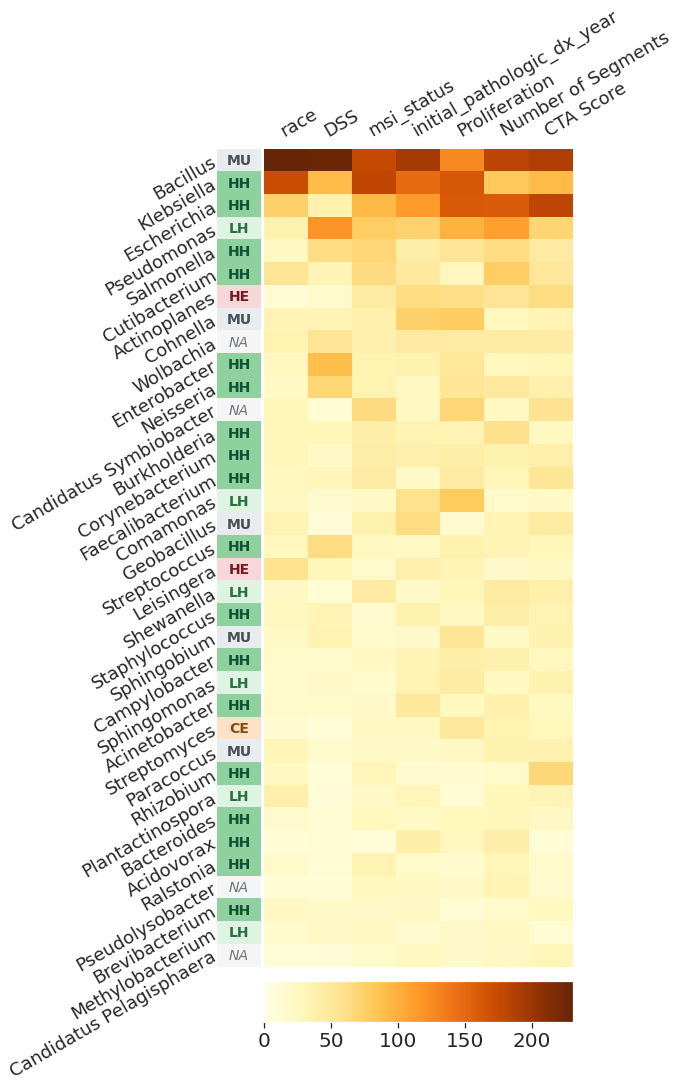

In [60]:
COAD_sorted_influence_df_subset = heatmap_influence(
    'COAD',
    COAD_sorted_influence_df,
    cmap="YlOrBr", #"Blues", "YlOrBr", "Reds"
    cbar=True,
    top_col_pct=0.02,
    save=True,
    taxa_names=True,
    horizontal=False,
    add_ecology_bar=True,
    row_label_fontsize=18,
    col_label_fontsize=18,
    anno_label_fontsize=14,
    colorbar_tick_fontsize=20
)

In [21]:
COAD_sorted_influence_df_subset

,Bacillus,Klebsiella,Escherichia,Pseudomonas,Salmonella,Cutibacterium,Actinoplanes,Cohnella,Wolbachia,Enterobacter,...,Paracoccus,Rhizobium,Plantactinospora,Bacteroides,Acidovorax,Ralstonia,Pseudolysobacter,Brevibacterium,Methylobacterium,Candidatus Pelagisphaera
race,230.776215,173.500549,74.562943,37.940075,26.562983,55.420322,13.707168,32.905315,35.918217,28.472729,...,31.684475,27.030003,41.093578,18.310192,10.867832,19.367037,11.364037,23.981743,18.192181,9.300110
DSS,227.749054,92.611259,38.112232,118.240242,63.627007,33.918961,18.784952,33.491722,55.393597,89.935799,...,18.651653,9.624449,10.734901,13.595461,13.271493,12.233605,10.978923,20.836214,22.672461,10.607287
msi_status,175.924240,179.778503,93.377144,78.107841,70.019051,65.303612,46.411568,39.050793,40.373741,35.766296,...,20.810810,31.708500,21.089785,28.857901,9.262315,34.814350,27.312792,19.907873,25.308413,19.175432
initial_pathologic_dx_year,194.672318,147.935608,114.298073,72.967819,43.509197,48.704529,64.170776,74.734123,48.340988,37.890865,...,20.942457,14.937949,32.261997,22.918308,43.070358,18.937099,26.166285,23.828592,16.796247,25.686213
Proliferation,126.972580,164.464722,162.076752,98.478119,54.281750,28.326374,61.652534,78.726852,46.236504,52.681381,...,24.010099,15.392347,11.955210,29.687895,28.455351,15.696831,21.578365,13.932353,20.555256,20.482769
Number of Segments,181.672333,80.263725,159.807037,111.409340,64.358543,77.967201,55.860367,28.801781,46.105602,28.388880,...,38.023750,19.210508,31.504887,30.815811,41.525105,32.258907,34.092049,18.507677,24.369595,23.519993
CTA Score,189.379410,92.256386,181.178177,70.483261,47.612122,51.929840,64.631996,32.485840,44.630035,31.289919,...,36.909328,68.642273,34.025608,24.244921,11.363466,18.939211,17.195013,26.422134,13.988270,31.371098


---

In [22]:
STAD_sorted_influence_df = sort_influence('STAD')

In [23]:
STAD_sorted_influence_df.columns[:5]

Index(['Klebsiella', 'Escherichia', 'Salmonella', 'Shigella',
       'Bradyrhizobium'],
      dtype='object')

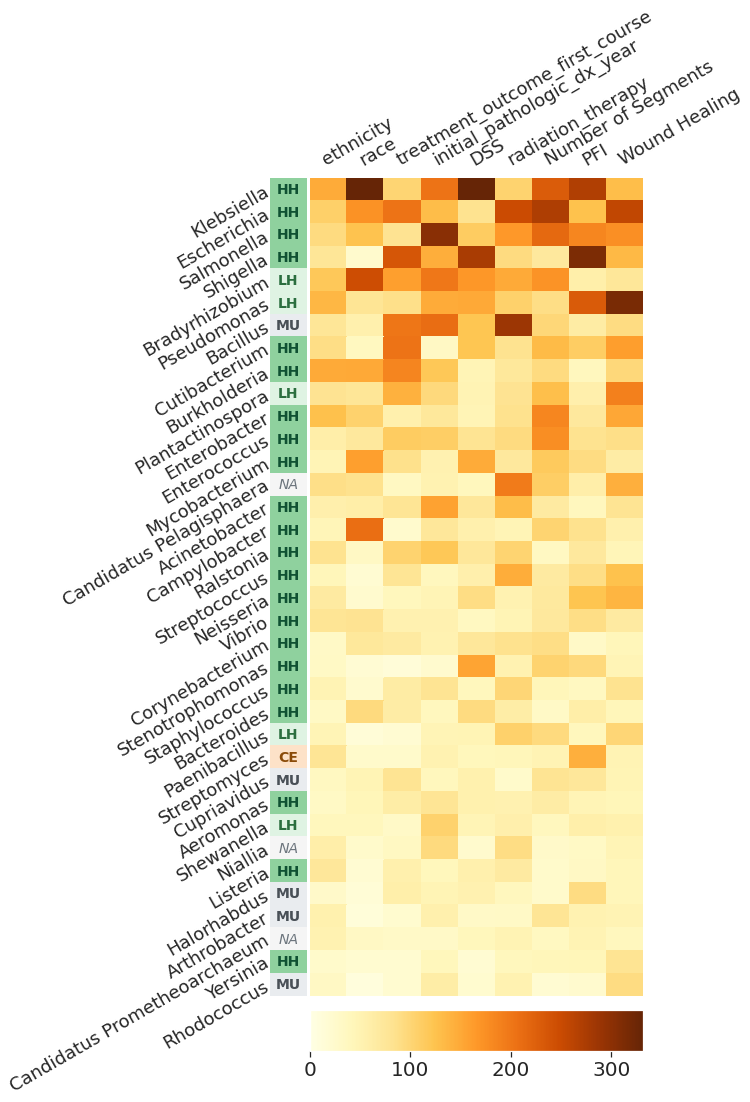

In [61]:
STAD_sorted_influence_df_subset = heatmap_influence(
    'STAD',
    STAD_sorted_influence_df,
    cmap="YlOrBr", #"Blues", "YlOrBr", "Reds"
    cbar=True,
    top_col_pct=0.02,
    save=True,
    taxa_names=True,
    horizontal=False,
    add_ecology_bar=True,
    row_label_fontsize=18,
    col_label_fontsize=18,
    anno_label_fontsize=14,
    colorbar_tick_fontsize=20
)

In [25]:
STAD_sorted_influence_df_subset

,Klebsiella,Escherichia,Salmonella,Shigella,Bradyrhizobium,Pseudomonas,Bacillus,Cutibacterium,Burkholderia,Plantactinospora,...,Cupriavidus,Aeromonas,Shewanella,Niallia,Listeria,Halorhabdus,Arthrobacter,Candidatus Prometheoarchaeum,Yersinia,Rhodococcus
ethnicity,148.214645,108.832382,93.958740,76.890816,118.685440,136.304611,77.687248,89.577187,150.307114,82.949081,...,36.630863,32.786186,41.314053,60.551598,74.928093,29.046776,55.483601,51.959579,27.070702,33.786091
race,332.080963,173.537079,125.639107,25.628107,247.173691,80.357300,55.963982,38.768322,151.500839,77.561134,...,48.063900,44.592926,40.628983,26.152323,20.624393,15.620748,12.912288,35.021702,20.840359,9.596561
treatment_outcome_first_course,101.354469,204.757614,82.763695,236.531006,159.734406,87.249313,202.037018,203.838287,185.929092,143.273468,...,81.560745,63.048409,30.509556,36.004143,56.030361,59.447510,22.056412,29.862284,21.377462,22.042967
initial_pathologic_dx_year,203.976685,131.959473,302.699310,145.835434,200.360733,148.505066,210.519638,34.512264,119.609680,96.367111,...,40.659145,79.206314,105.903770,95.932320,42.677864,48.484726,56.769619,31.054075,41.644855,62.321796
DSS,331.960663,83.899780,114.071526,277.289398,167.424332,151.377258,122.142891,122.567017,47.308868,50.350658,...,55.034855,54.950169,47.334538,24.939468,56.600266,54.340881,31.049105,42.717972,20.052414,22.832273
radiation_therapy,103.910492,250.351044,166.165665,93.602768,150.000717,107.350708,287.829529,84.181213,73.758934,82.572182,...,26.671064,53.286133,57.980621,91.833366,67.781891,38.969749,32.034836,49.769165,41.418945,52.360657
Number of Segments,230.462357,273.211365,216.398926,71.595070,172.160858,90.523315,99.017006,133.110901,93.933434,128.631409,...,81.008308,63.681873,40.030636,29.666256,27.190092,26.091192,79.213020,37.498257,43.099323,20.657114
PFI,271.446808,126.166267,185.266708,313.309601,58.706242,231.004929,65.916344,112.596649,40.140457,58.337788,...,73.996605,47.536415,58.880268,32.705624,34.682568,92.448036,52.208443,49.939346,45.265961,24.023438
Wound Healing,129.892960,257.463470,175.512589,135.152191,76.282951,315.542267,92.440269,161.413589,98.180298,190.929977,...,48.892227,45.056969,55.358055,47.144432,44.051331,43.249363,50.360622,39.098465,81.133980,92.465141


---
## Save LRP results seperately

In [64]:
def save_data_n_lrp(disease, save_folder='./', data_save_folder='../data/saved_data'):
    clinical_variables_disease_microbiome_clean = \
        pd.read_pickle('./data/processed data/{}_clinical_variables_disease_microbiome_clean.pkl'.format(disease))
    X_microbiome = pd.read_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))
    col_idx = clinical_variables_disease_microbiome_clean.shape[1] - X_microbiome.shape[1] - 4
    y_clinical_all = clinical_variables_disease_microbiome_clean.iloc[:,2:col_idx]
    data_save_folder1 = os.path.join(data_save_folder, f'{disease}')
    os.makedirs(data_save_folder1, exist_ok=True)
    X_microbiome.to_csv(os.path.join(data_save_folder1, 'X_microbiome.csv'))
    y_clinical_all.to_csv(os.path.join(data_save_folder1, 'y_clinical_all_cols.csv'))
    
    import pickle
    result_save_folder = os.path.join(save_folder, 'results/LRP/{}'.format(disease))
    os.makedirs(result_save_folder, exist_ok=True)
    with open(os.path.join(result_save_folder, 'lrp_result_dict.pkl'.format(disease)), "rb") as f:
        lrp_result_dict = pickle.load(f)
    
    R_0_clinical_all = lrp_result_dict['R_0_clinical_all']
    y_col_names = lrp_result_dict['y_col_names']
    
    for i, col in enumerate(y_col_names):
        classifier, optimizer, hist, X_test, y_test_le, classes, X_nonan, y_nonan_disc = \
            load_model(X=X_microbiome, y=y_clinical_all[col],
                       disease=disease, dropout_rate=0.4, weight_decay=0.1)
        R_0_df = pd.DataFrame(R_0_clinical_all[i], index=X_nonan.index, columns=X_nonan.columns)
        data_save_folder2 = os.path.join(data_save_folder, f'{disease}/{col}')
        os.makedirs(data_save_folder2, exist_ok=True)
        R_0_df.to_csv(os.path.join(data_save_folder2, 'R_0.csv'))
        X_nonan.to_csv(os.path.join(data_save_folder2, 'X_microbiome_nonan.csv'))
        

In [65]:
save_data_n_lrp('COAD')
save_data_n_lrp('STAD')

In [66]:
save_data_n_lrp('LUAD')
save_data_n_lrp('LUSC')